# Pima Indians Diabetes：糖尿病アウトカムとの関連

## 計画
run_id: `v020-exp-09`。Kaggle公開データをSDKで検索・取得し、SHA-256と取得日時で出典を固定する。型・重複・ゼロ・意味的な範囲を検査し、生理的に不自然なゼロを欠損として扱う。Outcome別の欠損率、観測値の分布、標準化群間差と信頼区間を比較し、点双列相関・調整ロジスティック回帰を行う。欠損処理と極端値処理の感度分析を行い、必要な追加分析を最大3回実行する。最後にカーネル再起動後、全コードセルを上からJupyter MCPで実行して根拠と図表を監査する。

結論は観察データ内の関連に限定する。糖尿病の原因・発症リスク・介入効果を推定したとは述べない。群別の補完はOutcomeを使うため行わない。予測性能評価や機械学習モデルの選択は本分析の目的ではない。

## 実行・保存経路
Notebookの作成・セル構築はproject_manager.ensure_notebook/enqueue_write、実行・出力保存はJupyter MCPのexecute_cellで行う。端末・subprocess・外部スクリプト・作業エージェントは利用しない。mcp_gateway.run_and_recordはPython側へMCPクライアントを注入する必要があるが、このCLIのツール接続はPythonオブジェクトとして提供されないため直接利用できない。偽のクライアントやexecで代替せず、実際のJupyter MCPで全コードを実行する。制御Notebookは構築・監査のみを担当する。

## 今回の再確認
既存の計画・3回の反復依頼原文を保持して結果を再読し、Kaggle APIで新規取得する。候補は実際の検索結果から選び、取得失敗時は残り候補へ進む。新規取得フォルダを使って古いCSV/ZIPの混入を避ける。診断定義・欠損機序・独立性は同じCSVでは解決できないため、4回目の追加モデル探索は行わない。再取得後、カーネルを再起動して全コードを順に再実行し、今回の監査記録で引渡し記録を更新する。


In [1]:
# 環境・ライフサイクル（全セルをJupyter MCP経由で実行）
from pathlib import Path
import os, sys, json, hashlib, io, contextlib, re
from datetime import datetime, timezone
from dataclasses import asdict
import nbformat
ROOT = Path('/home/nahisaho/GitHub/jupytermind')
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
os.environ['AI_DATA_SCIENTIST_PROJECTS_ROOT'] = str(ROOT / 'benchmark/projects')
from ai_data_scientist import project_manager as pm, lifecycle, language_router
from ai_data_scientist import ingestion, cleaning, eda, stats_analysis, visualization
from ai_data_scientist import data_definition, analysis_assumptions, data_quality, sensitivity
from ai_data_scientist import insight_engine, notebook_audit
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
from IPython.display import display, Markdown
handle = pm.resolve_project('kaggle-v020-kaggle-exp-09-diabetes')
pm.ensure_notebook(handle)
data_dir = pm.ensure_data_dir(handle)
run_id = 'v020-exp-09'
lifecycle.register_run(run_id, handle.notebook_path)
phase_log = []
@contextlib.contextmanager
def phase(name):
    if lifecycle.is_cancel_requested(run_id):
        raise RuntimeError('キャンセル要求を検出しました')
    lifecycle.mark_execution_start(run_id)
    phase_log.append({'phase': name, 'event': 'start', 'utc': datetime.now(timezone.utc).isoformat()})
    try:
        yield
    except Exception as error:
        lifecycle.mark_failed(run_id)
        phase_log.append({'phase': name, 'event': 'failed', 'error_type': type(error).__name__})
        raise
    finally:
        lifecycle.mark_execution_end(run_id)
        phase_log.append({'phase': name, 'event': 'end', 'utc': datetime.now(timezone.utc).isoformat()})
def write_notebook(mutation):
    phase_log.append({'phase':'notebook-write','event':'start','utc':datetime.now(timezone.utc).isoformat()})
    lifecycle.mark_write_start(run_id)
    try:
        pm.enqueue_write(handle, mutation)
    finally:
        lifecycle.mark_write_end(run_id)
        phase_log.append({'phase':'notebook-write','event':'end','utc':datetime.now(timezone.utc).isoformat()})
@contextlib.contextmanager
def write_phase(name):
    if lifecycle.is_cancel_requested(run_id):
        raise RuntimeError('キャンセル要求を検出しました')
    lifecycle.mark_write_start(run_id)
    phase_log.append({'phase':name,'event':'write_start','utc':datetime.now(timezone.utc).isoformat()})
    try:
        yield
    finally:
        lifecycle.mark_write_end(run_id)
        phase_log.append({'phase':name,'event':'write_end','utc':datetime.now(timezone.utc).isoformat()})
print('言語:', language_router.detect_language('糖尿病アウトカムとの関連を調べてください'))
print('run_id:', run_id)
print('実行経路: Jupyter MCP。認証情報は表示・保存しない。')


言語: ja
run_id: v020-exp-09
実行経路: Jupyter MCP。認証情報は表示・保存しない。


In [2]:
# Kaggle検索・ファイル列挙・取得（認証情報の出力禁止）
with phase('kaggle-acquisition'):
    requested_slug = 'uciml/pima-indians-diabetes-database'
    filename = 'diabetes.csv'
    selected_slug = None
    stage = 'import'
    failure = None
    search_refs, file_names, candidate_failures = [], [], []
    downloaded_path = data_dir / filename
    expected_columns = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']
    def safe_api_error(error, stage, slug=None):
        response = getattr(error, 'response', None)
        status = getattr(response, 'status_code', getattr(error, 'status', None))
        return {'slug':slug,'stage':stage,'error_type':type(error).__name__,
                'http_status':status if isinstance(status,int) else None,
                'reason':'秘密情報保護のためSDK例外本文・headers・設定は保存しない'}
    try:
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            from kaggle.api.kaggle_api_extended import KaggleApi
            api = KaggleApi()
            stage = 'authenticate'
            api.authenticate()
            stage = 'dataset_list'
            search_refs = [str(item.ref) for item in api.dataset_list(search='pima indians diabetes')]
            if requested_slug not in search_refs:
                search_refs = sorted(set(search_refs + [str(item.ref) for item in api.dataset_list(search='uciml pima indians diabetes')]))
            preferred = ['ahmedgamelwaly/pima-indians-diabetes','harsh146/pima-indians-diabetes']
            matched = [ref for ref in search_refs if ('pima' in ref.lower() or 'prima' in ref.lower()) and 'anti-pima' not in ref.lower()]
            candidates = [requested_slug] + [ref for ref in preferred if ref in matched] + [ref for ref in matched if ref not in preferred and ref != requested_slug]
            import zipfile
            attempt_root = data_dir / 'kaggle-downloads' / datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ')
            for candidate_index,candidate_slug in enumerate(candidates):
                try:
                    stage = 'dataset_list_files'
                    listing = api.dataset_list_files(candidate_slug)
                    candidate_files = [item.name for item in listing.files]
                    if filename not in candidate_files:
                        raise FileNotFoundError('対応CSVがファイル一覧に存在しない')
                    stage = 'dataset_download_file'
                    attempt_dir = attempt_root / str(candidate_index)
                    with write_phase('kaggle-file-download'):
                        attempt_dir.mkdir(parents=True,exist_ok=True)
                        api.dataset_download_file(candidate_slug,filename,path=str(attempt_dir),force=True,quiet=True)
                        csv_path = attempt_dir / filename
                        if csv_path.exists():
                            payload = csv_path.read_bytes()
                        else:
                            zipped_path = attempt_dir / (filename + '.zip')
                            if not zipped_path.exists():
                                raise FileNotFoundError('新規取得フォルダにCSVもZIPもない')
                            with zipfile.ZipFile(zipped_path) as archive:
                                payload = archive.read(filename)
                    stage = 'candidate-schema-check'
                    candidate_frame = pd.read_csv(io.BytesIO(payload))
                    if list(candidate_frame.columns) != expected_columns or candidate_frame.shape != (768,9):
                        raise ValueError('古典的Pimaデータの768行9列スキーマに不一致')
                    with write_phase('adopt-downloaded-csv'):
                        downloaded_path.write_bytes(payload)
                    selected_slug, file_names = candidate_slug,candidate_files
                    break
                except Exception as candidate_error:
                    candidate_failures.append(safe_api_error(candidate_error,stage,candidate_slug))
            if selected_slug is None:
                raise LookupError('指定slugと検索から得た対応候補の取得がすべて失敗')
        source_kind = 'kaggle'
        source_url = 'https://www.kaggle.com/datasets/' + selected_slug
    except Exception as error:
        failure = safe_api_error(error,stage)
        import urllib.request
        source_url = 'https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv'
        legacy_note = Path('/home/nahisaho/kaggle/experiments/white-paper.md')
        legacy_checked = legacy_note.exists() and source_url in legacy_note.read_text(encoding='utf-8')
        with urllib.request.urlopen(source_url,timeout=30) as response:
            payload = response.read()
        with write_phase('fallback-csv-write'):
            downloaded_path.write_bytes(payload)
        source_kind = 'fallback-public-csv'
    retrieved_utc = datetime.now(timezone.utc).isoformat()
    sha256 = hashlib.sha256(downloaded_path.read_bytes()).hexdigest()
    provenance = {'requested_owner_dataset_slug':requested_slug,'owner_dataset_slug':selected_slug,
        'source_kind':source_kind,'source_url':source_url,'retrieved_filename':filename,
        'retrieved_at_utc':retrieved_utc,'sha256':sha256,'search_query':'pima indians diabetes',
        'candidate_failures':candidate_failures,'search_results':search_refs,'kaggle_file_names':file_names,
        'kaggle_failure':failure,'fallback_reason':None if failure is None else 'Kaggle検索・対応候補取得を完了できなかったため、指定された旧実験の公開CSVを使用',
        'legacy_note_url_confirmed':None if failure is None else legacy_checked,
        'identity_warning':('対応する別ownerのKaggle公開版。参照指定uciml版との完全な同一性は未検証' if selected_slug != requested_slug else None) if failure is None else '公開CSVとKaggle掲載版の完全な同一性は保証されない'}
    provenance_path = data_dir / 'provenance.json'
    if provenance_path.exists():
        prior_provenance = json.loads(provenance_path.read_text(encoding='utf-8'))
        print('前回取得SHAとの一致:', prior_provenance['sha256'] == sha256)
        assert prior_provenance['sha256'] == sha256, 'ファイルSHAが変化したため既存結論との再現性判定を中止'
    with write_phase('provenance-write'):
        provenance_path.write_text(json.dumps(provenance,ensure_ascii=False,indent=2),encoding='utf-8')
    display(Markdown('### 取得記録\n```json\n'+json.dumps(provenance,ensure_ascii=False,indent=2)+'\n```'))
    loaded = ingestion.ingest(ingestion.SourceSpec('csv',str(downloaded_path)),row_limit=10000)
    raw = loaded.dataframe
    assert not loaded.truncated and list(raw.columns)==expected_columns
    display(raw.head())
    print('データ形状:',raw.shape)


前回取得SHAとの一致: True
データ形状: (768, 9)


### 取得記録
```json
{
  "requested_owner_dataset_slug": "uciml/pima-indians-diabetes-database",
  "owner_dataset_slug": "harsh146/pima-indians-diabetes",
  "source_kind": "kaggle",
  "source_url": "https://www.kaggle.com/datasets/harsh146/pima-indians-diabetes",
  "retrieved_filename": "diabetes.csv",
  "retrieved_at_utc": "2026-10-01T20:14:59.960109+00:00",
  "sha256": "698c203a14aa31941d2251175330c9199f3ccdb31597abbba2a3e35416257a72",
  "search_query": "pima indians diabetes",
  "candidate_failures": [
    {
      "slug": "uciml/pima-indians-diabetes-database",
      "stage": "dataset_list_files",
      "error_type": "HTTPError",
      "http_status": 403,
      "reason": "秘密情報保護のためSDK例外本文・headers・設定は保存しない"
    },
    {
      "slug": "ahmedgamelwaly/pima-indians-diabetes",
      "stage": "dataset_list_files",
      "error_type": "FileNotFoundError",
      "http_status": null,
      "reason": "秘密情報保護のためSDK例外本文・headers・設定は保存しない"
    }
  ],
  "search_results": [
    "agileteam/bigdatacertificationkr",
    "ahmedgamelwaly/pima-indians-diabetes",
    "ameythakur20/data-science-machine-learning-and-ai-using-python",
    "amineipad/diabetes-dataset",
    "danushkumarv/diabetes-dataset",
    "fathyfathysahlool/pima-and-indians-diabetes",
    "harsh146/pima-indians-diabetes",
    "jamaltariqcheema/pima-indians-diabetes-dataset",
    "jameshramos/pima-indians-diabetes",
    "kumargh/pimaindiansdiabetescsv",
    "lianglirong/pima-indians-onset-of-diabetes",
    "maunish/prima-indiansdiabetes",
    "mragpavank/diabetes",
    "philanipro/pima-indians-diabetes",
    "prashantsatpute/pima-indians-diabetes",
    "rahibvk/real-diabetes-lab-results-and-biomarkers-anti-pima",
    "salihacur/diabetes",
    "sandeep2812/pimaindiansdiabetes",
    "semakulapaul/pimaindiansdiabetes",
    "wanglaiqi/pimaindiansdiabetesdata"
  ],
  "kaggle_file_names": [
    "diabetes.csv"
  ],
  "kaggle_failure": null,
  "fallback_reason": null,
  "legacy_note_url_confirmed": null,
  "identity_warning": "対応する別ownerのKaggle公開版。参照指定uciml版との完全な同一性は未検証"
}
```

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## データ処理・統計の事前方針
Glucose・BloodPressure・SkinThickness・Insulin・BMIの0は生理的に不自然な値と判断してNaNへ変換する。妊娠回数0とOutcome=0は有効値として残す。意味的検査の広い上下限は診断閾値ではなく明らかなコード異常を見つけるための便宜的範囲。正の高値は誤入力と断定せず主解析で保持し、1/99パーセンタイルへのWinsor化を感度分析に限る。

単変量比較は列ごとの観測値で行い、nを表示する。Hedges gはOutcome=1−0の標準化平均差、CIは群別2000回bootstrap（seed固定）、点双列相関のp値は8特徴のBH補正を併記する。全列共通の標本ではないので順位は探索的。調整分析は全特徴と5列の欠損指示変数、Outcome非参照の全体中央値補完を主解析に用いる。完全例およびWinsor化と比較し、同じ観測SDに標準化して係数を比較する。ORをリスク比と呼ばない。単一補完のCIは補完不確実性を反映しない。

単位・対象母集団・ラベル定義は取得CSVだけから検証できないものをinferred/unknownとして表示する。診断基準と時間順序が不明なため、特にGlucoseとの強い関連にはラベル定義との近接性があり得る。独立した参照データがないためデータセット間の検証は適用不可。モデルの形式や未測定交絡が正しいと保証せず、因果識別・将来予測の検証・外的妥当性検証は行わない。


In [3]:
# データ定義manifest・意味的異常検査・欠損処理
with phase('data-definition-and-cleaning'):
    features = [c for c in raw.columns if c != 'Outcome']
    zero_missing = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
    definitions = {
      'Pregnancies': ('妊娠回数', '回'), 'Glucose': ('グルコース測定値（負荷後測定と推定、時点は未確認）','mg/dLと推定'),
      'BloodPressure': ('拡張期血圧と推定','mmHgと推定'), 'SkinThickness': ('上腕三頭筋皮下厚と推定','mmと推定'),
      'Insulin': ('インスリン測定値（測定時点は未確認）','µU/mLと推定'), 'BMI': ('体格指数と推定','kg/m²と推定'),
      'DiabetesPedigreeFunction': ('糖尿病家族歴に関する指標と推定（算式未確認）','指標値'),
      'Age': ('年齢と推定','年と推定'), 'Outcome': ('糖尿病に関する二値ラベル、1を陽性と推定','0/1')}
    FV = data_definition.FieldValue
    variables = {col: {'definition': FV(text, 'inferred', provenance['source_url']),
                       'unit': FV(unit, 'inferred', '列名と既知のPimaデータ辞書を参考。ただし掲載版の辞書は検証できていない')} for col,(text,unit) in definitions.items()}
    variables['Outcome']['diagnostic_criteria'] = FV(None, 'unknown', 'CSVに診断基準が含まれない')
    variables['Outcome']['measurement_timing'] = FV(None, 'unknown', '説明変数との時間順序を確認できない')
    definition_manifest = data_definition.build_manifest(
      source={'url': FV(provenance['source_url'],'verified','取得記録'),
              'sha256': FV(sha256,'verified','取得ファイル計算'),
              'license': FV(None,'unknown','CSV単体からライセンスを確認できない')},
      dataset_scope={'population': FV('Pima集団の成人女性（21歳以上）とされるデータ。今回のCSVだけでは属性を検証できない','inferred', 'Kaggle参照先・列名'),
                     'sampling_frame': FV(None,'unknown','標本抽出方法は未確認'),
                     'row_count': FV(len(raw),'verified','読込結果')},
      variables=variables, transformations=('5列のゼロをNaNへ変換。Pregnanciesの0は保持。正の極端値は主解析で保持。',))
    print('データ定義manifest:', json.dumps(asdict(definition_manifest), ensure_ascii=False, default=str))
    print('unknown fields:', [(k,asdict(v)) for k,v in definition_manifest.unresolved_fields()])
    inferred_fields = [f'variables.{col}.{field}' for col,fields in variables.items() for field,value in fields.items() if value.status == 'inferred']
    print('inferred fields（別途列挙）:', inferred_fields)
    broad_bounds = {'Pregnancies':(0,30),'Glucose':(1,600),'BloodPressure':(1,250),
        'SkinThickness':(1,150),'Insulin':(1,3000),'BMI':(1,100),'DiabetesPedigreeFunction':(0,10),'Age':(21,120)}
    schema = {col:{'min':lo,'max':hi,'not_null':True} for col,(lo,hi) in broad_bounds.items()}
    schema['Outcome'] = {'allowed':[0,1],'not_null':True}
    semantic_issues = data_quality.detect_anomalies(raw, schema)
    display(pd.DataFrame([asdict(x) for x in semantic_issues]).drop(columns='row_indices', errors='ignore'))
    print('整数性違反:', {c:int((raw[c] % 1 != 0).sum()) for c in ['Pregnancies','Age','Outcome']})
    print('元のNA数:', int(raw.isna().sum().sum()), '重複行数:', int(raw.duplicated().sum()))
    duplicate_report = cleaning.clean_dataset(raw, operation='drop_duplicates')
    print('重複除去影響:', {'rows_before':duplicate_report.rows_before,'rows_after':duplicate_report.rows_after,'rows_removed':duplicate_report.rows_removed,'columns_affected':duplicate_report.columns_affected})
    clean = duplicate_report.dataframe.copy()
    clean[zero_missing] = clean[zero_missing].mask(clean[zero_missing].eq(0))
    assert len(clean) == len(raw), '重複が存在する場合は解析単位を再検討する'
    assert clean['Outcome'].isin([0,1]).all()
    print('ゼロ→欠損の列別件数:', clean[zero_missing].isna().sum().to_dict())
    missing_table = pd.DataFrame({'missing_n': clean[features].isna().sum(), 'missing_pct': clean[features].isna().mean()*100})
    for outcome in [0,1]:
        group = clean.loc[clean.Outcome == outcome, features]
        missing_table[f'Outcome{outcome}_n'] = group.isna().sum()
        missing_table[f'Outcome{outcome}_pct'] = group.isna().mean()*100
    display(missing_table.round(3))
    explore_report = eda.explore(clean)
    print('EDA型:', clean.dtypes.to_dict())
    display(clean.describe().T)
    print('EDA欠損サマリ:', explore_report.missing_summary)
    print('EDA非欠損件数:', explore_report.non_null_counts)
    assumptions_manifest = analysis_assumptions.AnalysisAssumptionManifest(
      analysis_scope={'target':'この標本内のOutcomeと各特徴の関連','generalization':'外部集団・将来発症への外挿はしない'},
      causal_scope='associational', sampling={'n':len(clean),'seed':20261002},
      assumptions=(
        analysis_assumptions.Assumption('zero-as-missing','5列の0は欠測コードとみなす','assumed',impact_if_false='測定定義や関連の推定が変わる',conclusion_critical=True),
        analysis_assumptions.Assumption('independent-rows','各行は独立した観測と仮定。個人IDがなく再測定は検証できない','assumed',impact_if_false='CI・検定の精度が過大になる',conclusion_critical=True),
        analysis_assumptions.Assumption('outcome-semantics','Outcome=1を糖尿病陽性として解釈する。診断基準と時間順序は不明','assumed',impact_if_false='臨床的解釈が変わる',conclusion_critical=True),
        analysis_assumptions.Assumption('missingness','完全例・中央値補完で欠損バイアスを解消できるとは仮定しない','rejected',impact_if_false='欠損が非ランダムなら関連が偏る'),
        analysis_assumptions.Assumption('causality','観察的関連のみ。因果識別の設計はない','verified',impact_if_false='因果への誤解を招く')))
    print('分析前提manifest:', json.dumps(asdict(assumptions_manifest),ensure_ascii=False))
    assumption_findings = analysis_assumptions.check_manifest(assumptions_manifest)
    for finding in assumption_findings:
        print('前提の未解決警告:', asdict(finding))
    print('適用不可: 独立した参照データは未提供。validate_anomalies/compare_datasetsは同一由来の複製を独立検証と誤認しないため使用しない。z-scoreによる一律削除も歪んだ分布・真の高値を誤削除するため行わない。')


データ定義manifest: {"source": {"url": {"value": "https://www.kaggle.com/datasets/harsh146/pima-indians-diabetes", "status": "verified", "source": "取得記録"}, "sha256": {"value": "698c203a14aa31941d2251175330c9199f3ccdb31597abbba2a3e35416257a72", "status": "verified", "source": "取得ファイル計算"}, "license": {"value": null, "status": "unknown", "source": "CSV単体からライセンスを確認できない"}}, "dataset_scope": {"population": {"value": "Pima集団の成人女性（21歳以上）とされるデータ。今回のCSVだけでは属性を検証できない", "status": "inferred", "source": "Kaggle参照先・列名"}, "sampling_frame": {"value": null, "status": "unknown", "source": "標本抽出方法は未確認"}, "row_count": {"value": 768, "status": "verified", "source": "読込結果"}}, "variables": {"Pregnancies": {"definition": {"value": "妊娠回数", "status": "inferred", "source": "https://www.kaggle.com/datasets/harsh146/pima-indians-diabetes"}, "unit": {"value": "回", "status": "inferred", "source": "列名と既知のPimaデータ辞書を参考。ただし掲載版の辞書は検証できていない"}}, "Glucose": {"definition": {"value": "グルコース測定値（負荷後測定と推定、時点は未確認）", "status": "inferred

,column,rule,row_count,message
0,Glucose,range,5,"Column 'Glucose' has 5 value(s) outside [1, 600]."
1,BloodPressure,range,35,Column 'BloodPressure' has 35 value(s) outside...
2,SkinThickness,range,227,Column 'SkinThickness' has 227 value(s) outsid...
3,Insulin,range,374,"Column 'Insulin' has 374 value(s) outside [1, ..."
4,BMI,range,11,"Column 'BMI' has 11 value(s) outside [1, 100]."


,missing_n,missing_pct,Outcome0_n,Outcome0_pct,Outcome1_n,Outcome1_pct
Pregnancies,0,0.000,0,0.0,0,0.000
Glucose,5,0.651,3,0.6,2,0.746
BloodPressure,35,4.557,19,3.8,16,5.970
SkinThickness,227,29.557,139,27.8,88,32.836
Insulin,374,48.698,236,47.2,138,51.493
BMI,11,1.432,9,1.8,2,0.746
DiabetesPedigreeFunction,0,0.000,0,0.0,0,0.000
Age,0,0.000,0,0.0,0,0.000


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,763.0,121.686763,30.535641,44.000,99.00000,117.0000,141.00000,199.00
BloodPressure,733.0,72.405184,12.382158,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,541.0,29.153420,10.476982,7.000,22.00000,29.0000,36.00000,99.00
Insulin,394.0,155.548223,118.775855,14.000,76.25000,125.0000,190.00000,846.00
BMI,757.0,32.457464,6.924988,18.200,27.50000,32.3000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [4]:
# Outcome別比較、点双列相関、効果量・95%CI（観測値のみ）
with phase('univariate-association'):
    from statsmodels.stats.multitest import multipletests
    group_counts = clean.Outcome.value_counts().sort_index()
    summary = {'n': len(clean), 'positive': int(group_counts[1]), 'negative': int(group_counts[0]), 'positive_pct': clean.Outcome.mean()*100}
    display(Markdown('### 標本構成\n```json\n'+json.dumps(summary)+'\n```'))
    rng = np.random.default_rng(20261002)
    rows = []
    def hedges_g(a,b):
        pooled = np.sqrt(((len(a)-1)*np.var(a,ddof=1)+(len(b)-1)*np.var(b,ddof=1))/(len(a)+len(b)-2))
        return (1-3/(4*(len(a)+len(b))-9))*(np.mean(b)-np.mean(a))/pooled
    for column in features:
        available = clean[[column,'Outcome']].dropna()
        a = available.loc[available.Outcome==0,column].to_numpy()
        b = available.loc[available.Outcome==1,column].to_numpy()
        stat = stats_analysis.correlation(available, column, 'Outcome', language='ja')
        boot_a = rng.choice(a, size=(2000,len(a)),replace=True)
        boot_b = rng.choice(b, size=(2000,len(b)),replace=True)
        pooled_boot = np.sqrt(((len(a)-1)*boot_a.var(axis=1,ddof=1)+(len(b)-1)*boot_b.var(axis=1,ddof=1))/(len(a)+len(b)-2))
        boot_g = (1-3/(4*(len(a)+len(b))-9))*(boot_b.mean(axis=1)-boot_a.mean(axis=1))/pooled_boot
        lo,hi = np.quantile(boot_g,[.025,.975])
        rows.append({'feature':column,'n0':len(a),'n1':len(b),'median0':np.median(a),'median1':np.median(b),
            'Q1_0':np.quantile(a,.25),'Q3_0':np.quantile(a,.75),'Q1_1':np.quantile(b,.25),'Q3_1':np.quantile(b,.75),
            'mean0':a.mean(),'mean1':b.mean(),'hedges_g':hedges_g(a,b),'g_ci_low':lo,'g_ci_high':hi,
            'point_biserial_r':stat.statistic,'p':stat.p_value,'interpretation':stat.interpretation})
    association = pd.DataFrame(rows).set_index('feature')
    association['q_BH'] = multipletests(association['p'],method='fdr_bh')[1]
    association_display = association.drop(columns='interpretation').round(6)
    for p_column in ['p','q_BH']:
        association_display[p_column] = association[p_column].map(lambda value: f'{value:.3e}')
    display(association_display)
    display(Markdown('### 相関の解釈\n'+ '\n\n'.join(f'**{column}**: {row.interpretation} 二値OutcomeとのPearson相関は点双列相関に相当し、因果関係は示さない。' for column,row in association.iterrows())))
    display(Markdown('### 引用用出力\n```json\n'+json.dumps({'Glucose_r':round(association.loc['Glucose','point_biserial_r'],6),'Glucose_g':round(association.loc['Glucose','hedges_g'],6),'BMI_r':round(association.loc['BMI','point_biserial_r'],6),'Age_r':round(association.loc['Age','point_biserial_r'],6),'Insulin_missing_pct':round(missing_table.loc['Insulin','missing_pct'],6)},ensure_ascii=False)+'\n```'))


### 標本構成
```json
{"n": 768, "positive": 268, "negative": 500, "positive_pct": 34.89583333333333}
```

,n0,n1,median0,median1,Q1_0,Q3_0,Q1_1,Q3_1,mean0,mean1,hedges_g,g_ci_low,g_ci_high,point_biserial_r,p,q_BH
feature,,,,,,,,,,,,,,,,
Pregnancies,500,268,2.000,4.000,1.00000,5.00000,1.7500,8.000,3.298000,4.865672,0.476360,0.318060,0.632316,0.221898,5.065e-10,1.013e-09
Glucose,497,266,107.000,140.000,93.00000,125.00000,119.0000,167.000,110.643863,142.319549,1.191625,1.018159,1.366606,0.494650,2.478e-48,1.983e-47
BloodPressure,481,252,70.000,74.500,62.00000,78.00000,68.0000,84.000,70.877339,75.321429,0.363627,0.209528,0.515401,0.170589,3.405e-06,3.405e-06
SkinThickness,361,180,27.000,32.000,19.00000,33.00000,27.0000,39.000,27.235457,33.000000,0.568406,0.389602,0.748806,0.259491,8.960e-10,1.195e-09
Insulin,264,130,102.500,169.500,66.00000,161.25000,127.5000,239.250,130.287879,206.846154,0.674304,0.438176,0.918738,0.303454,7.755e-10,1.195e-09
BMI,491,266,30.100,34.300,25.60000,35.30000,30.9000,38.925,30.859674,35.406767,0.690379,0.551208,0.847752,0.313680,9.546e-19,3.818e-18
DiabetesPedigreeFunction,500,268,0.336,0.449,0.22975,0.56175,0.2625,0.728,0.429734,0.550500,0.369522,0.213324,0.523914,0.173844,1.255e-06,1.434e-06
Age,500,268,27.000,36.000,23.00000,37.00000,28.0000,44.000,31.190000,37.067164,0.513741,0.365128,0.673508,0.238356,2.210e-11,5.893e-11


### 相関の解釈
**Pregnancies**: 相関係数は 0.2219 (p=5.065e-10) で、弱い正の相関が見られます。 二値OutcomeとのPearson相関は点双列相関に相当し、因果関係は示さない。

**Glucose**: 相関係数は 0.4947 (p=2.478e-48) で、中程度の正の相関が見られます。 二値OutcomeとのPearson相関は点双列相関に相当し、因果関係は示さない。

**BloodPressure**: 相関係数は 0.1706 (p=3.405e-06) で、弱い正の相関が見られます。 二値OutcomeとのPearson相関は点双列相関に相当し、因果関係は示さない。

**SkinThickness**: 相関係数は 0.2595 (p=8.96e-10) で、弱い正の相関が見られます。 二値OutcomeとのPearson相関は点双列相関に相当し、因果関係は示さない。

**Insulin**: 相関係数は 0.3035 (p=7.755e-10) で、中程度の正の相関が見られます。 二値OutcomeとのPearson相関は点双列相関に相当し、因果関係は示さない。

**BMI**: 相関係数は 0.3137 (p=9.546e-19) で、中程度の正の相関が見られます。 二値OutcomeとのPearson相関は点双列相関に相当し、因果関係は示さない。

**DiabetesPedigreeFunction**: 相関係数は 0.1738 (p=1.255e-06) で、弱い正の相関が見られます。 二値OutcomeとのPearson相関は点双列相関に相当し、因果関係は示さない。

**Age**: 相関係数は 0.2384 (p=2.21e-11) で、弱い正の相関が見られます。 二値OutcomeとのPearson相関は点双列相関に相当し、因果関係は示さない。

### 引用用出力
```json
{"Glucose_r": 0.49465, "Glucose_g": 1.191625, "BMI_r": 0.31368, "Age_r": 0.238356, "Insulin_missing_pct": 48.697917}
```

初回Insight・相関の解釈：Glucoseの点双列相関はr=0.49465で、この8特徴の観測値比較では最も大きい。BMI・Insulin・年齢などにも正の単変量関連があるが、列ごとに観測標本が異なり、相関は原因を示さない。

```evidence
{"execution_count":4,"cited_value":"0.49465","claim_type":"associational"}
```

欠損のInsight：Insulinの欠損率は48.697917%。ゼロ→NaNの仮定に基づく値であり、観測Insulinの関連を全標本へそのまま外挿できない。SkinThicknessも約29.6%欠損。診断基準と欠損機序は未検証。

```evidence
{"execution_count":4,"cited_value":"48.697917","claim_type":"descriptive"}
```

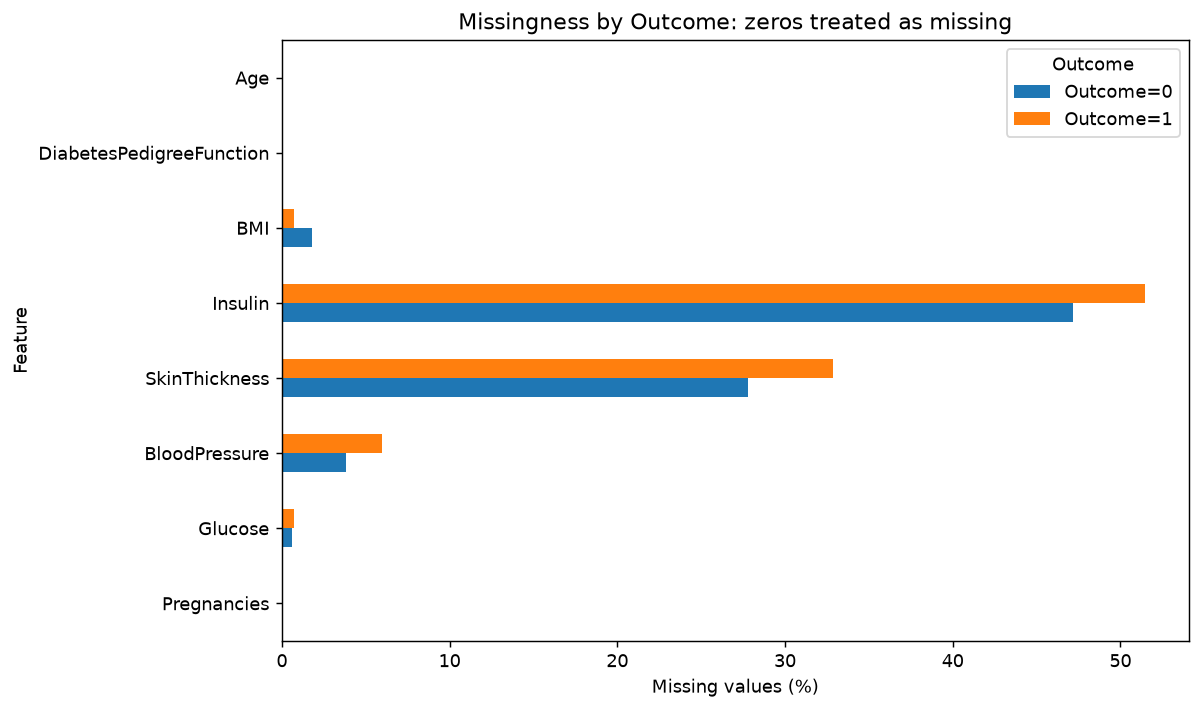

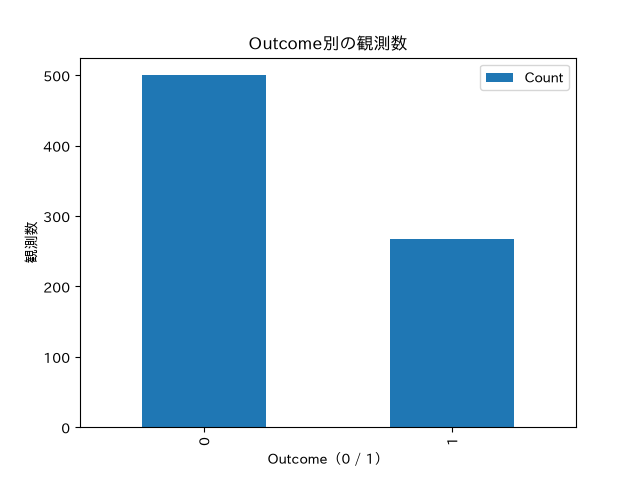

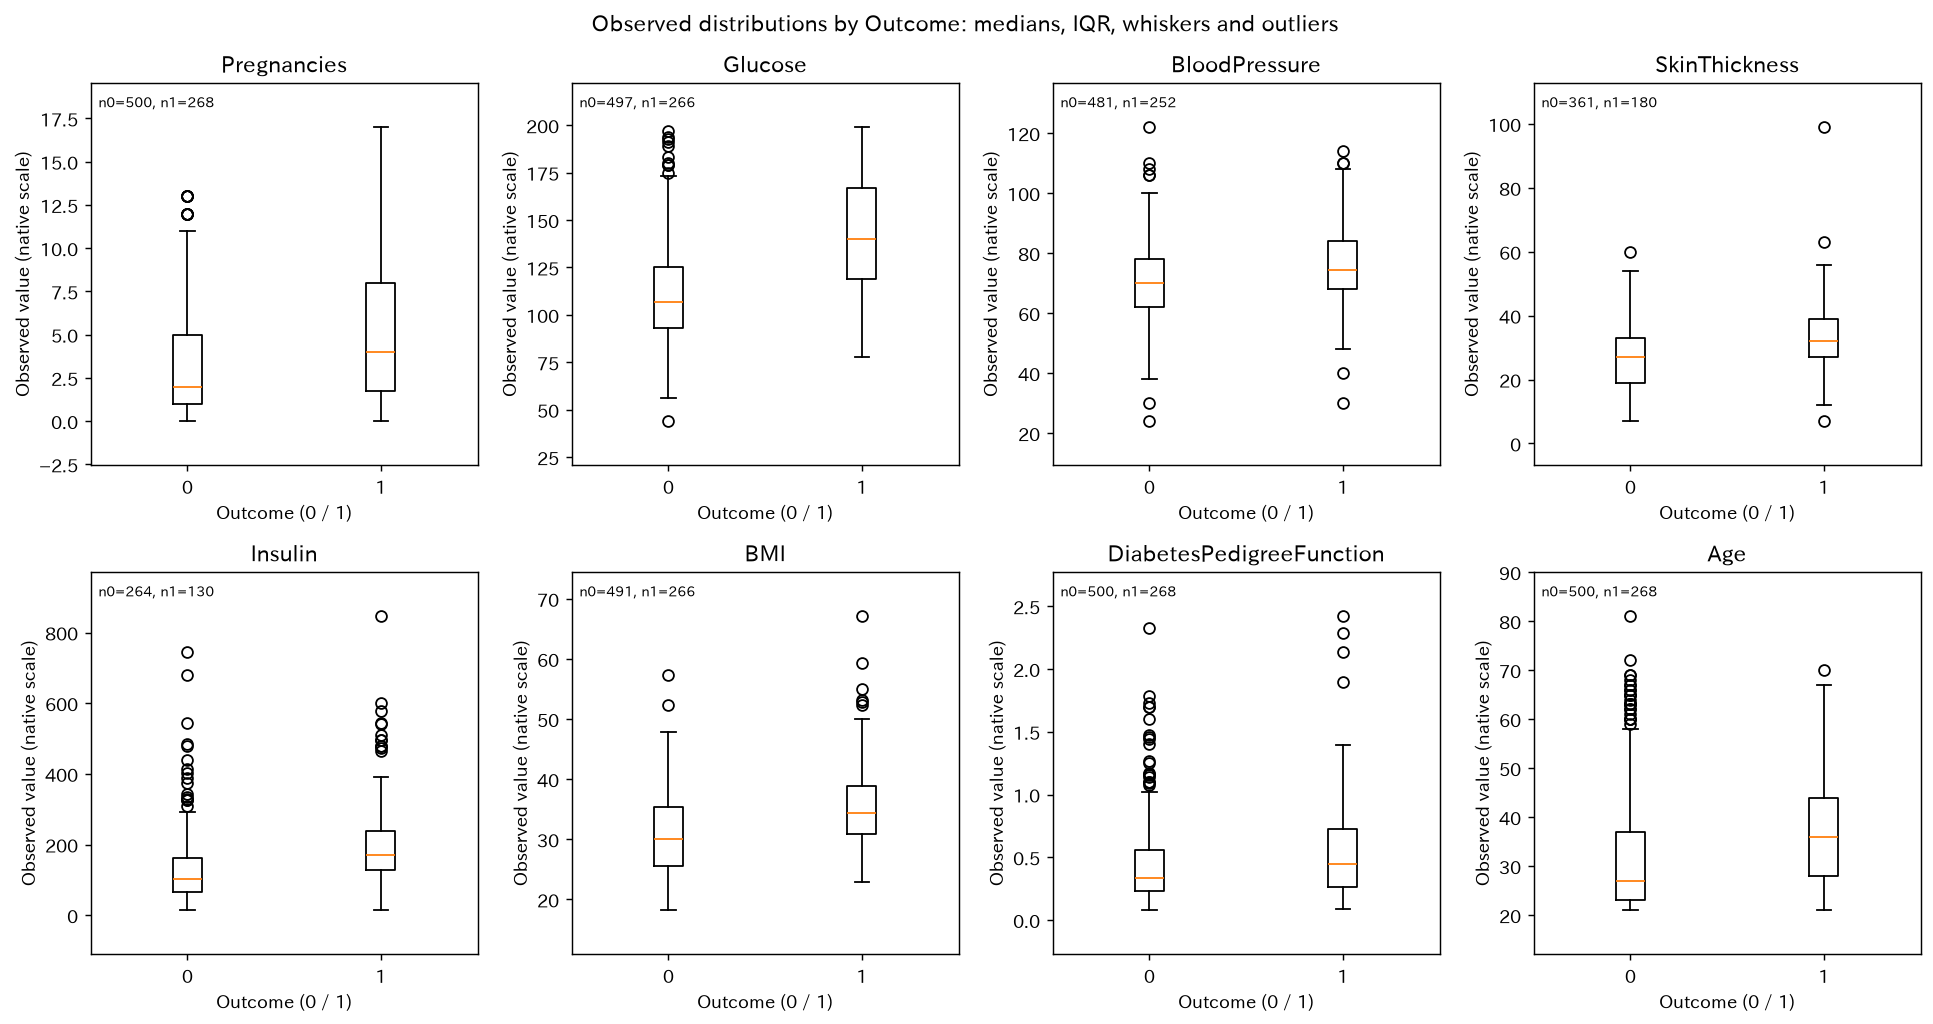

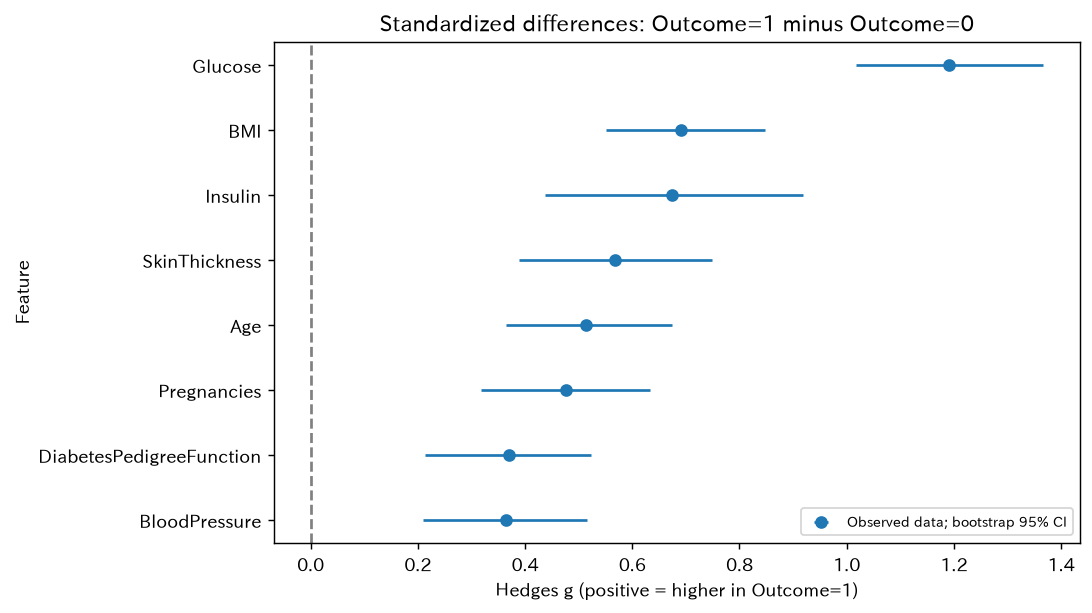

In [5]:
# 比較図：欠損率、群別分布、標準化群間差。各図はNotebookにPNGを保存。
with phase('comparison-visualization'):
    import matplotlib.pyplot as plt
    import warnings
    def show_png(png):
        output = visualization.build_image_output(png)
        display(output['data'], raw=True)
    def show_figure(fig):
        with warnings.catch_warnings(record=True) as messages:
            warnings.simplefilter('always')
            buf = io.BytesIO()
            fig.savefig(buf,format='png',dpi=130,bbox_inches='tight')
        plt.close(fig)
        missing_glyph_messages = [str(w.message) for w in messages if 'Glyph' in str(w.message) and 'missing' in str(w.message)]
        if missing_glyph_messages:
            raise RuntimeError('文字欠落を検出: '+repr(missing_glyph_messages))
        show_png(buf.getvalue())
    missing_plot = missing_table[['Outcome0_pct','Outcome1_pct']].rename(columns={'Outcome0_pct':'Outcome=0','Outcome1_pct':'Outcome=1'})
    fig,ax = plt.subplots(figsize=(9,6))
    missing_plot.plot.barh(ax=ax)
    ax.set(title='Missingness by Outcome: zeros treated as missing',xlabel='Missing values (%)',ylabel='Feature')
    ax.legend(title='Outcome')
    show_figure(fig)
    counts_plot = pd.DataFrame({'Outcome':['0','1'],'Count':[int(group_counts[0]),int(group_counts[1])]})
    with warnings.catch_warnings(record=True) as messages:
        warnings.simplefilter('always')
        png = visualization.render_chart(counts_plot,kind='bar',x='Outcome',y='Count',title='Outcome別の観測数',xlabel='Outcome（0 / 1）',ylabel='観測数')
    assert not any('Glyph' in str(w.message) and 'missing' in str(w.message) for w in messages)
    show_png(png)
    fig,axes = plt.subplots(2,4,figsize=(15,8))
    for ax,column in zip(axes.flat,features):
        samples = [clean.loc[clean.Outcome==outcome,column].dropna() for outcome in [0,1]]
        ax.boxplot(samples,tick_labels=['0','1'],showfliers=True)
        ax.margins(y=.15)
        ax.set_title(column)
        ax.set_xlabel('Outcome (0 / 1)')
        ax.set_ylabel('Observed value (native scale)')
        ax.text(.02,.97,f'n0={len(samples[0])}, n1={len(samples[1])}',transform=ax.transAxes,va='top',fontsize=8)
    fig.suptitle('Observed distributions by Outcome: medians, IQR, whiskers and outliers')
    fig.tight_layout()
    show_figure(fig)
    ordered = association.sort_values('hedges_g')
    fig,ax = plt.subplots(figsize=(8,5))
    ax.errorbar(ordered.hedges_g,ordered.index,xerr=[ordered.hedges_g-ordered.g_ci_low,ordered.g_ci_high-ordered.hedges_g],fmt='o',label='Observed data; bootstrap 95% CI')
    ax.axvline(0,color='gray',linestyle='--')
    ax.set(title='Standardized differences: Outcome=1 minus Outcome=0',xlabel='Hedges g (positive = higher in Outcome=1)',ylabel='Feature')
    ax.legend(loc='lower right',fontsize=8)
    show_figure(fig)


In [6]:
# 調整ロジスティック回帰と欠損処理・極端値処理の感度分析
with phase('adjusted-association-and-sensitivity'):
    scale = clean[features].std(ddof=1)
    center = clean[features].mean()
    model_cache = {}
    def fit_model(strategy='median',tail='keep',indicators=True):
        key = (strategy,tail,indicators)
        if key in model_cache:
            return model_cache[key]
        work = clean.copy()
        if tail == 'winsor':
            for column in features:
                lo,hi = work[column].quantile([.01,.99])
                work[column] = work[column].clip(lo,hi)
        elif tail != 'keep':
            raise ValueError(tail)
        if strategy == 'complete':
            work = work.dropna(subset=features)
            x = (work[features]-center)/scale
        elif strategy == 'median':
            x = (work[features].fillna(work[features].median())-center)/scale
            if indicators:
                for column in zero_missing:
                    x[column+'_missing'] = work[column].isna().astype(int)
        else:
            raise ValueError(strategy)
        fitted = sm.GLM(work.Outcome,sm.add_constant(x),family=sm.families.Binomial()).fit()
        assert fitted.converged
        model_cache[key] = (fitted,len(work))
        return fitted,len(work)
    main_model,main_n = fit_model()
    ci = main_model.conf_int()
    adjusted = pd.DataFrame({'beta':main_model.params,'adjusted_OR_per_SD':np.exp(main_model.params),
        'CI_low':np.exp(ci[0]),'CI_high':np.exp(ci[1]),'p':main_model.pvalues}).drop('const')
    display(adjusted.round(6))
    print('主解析n:',main_n,'全体の観測SDを共通基準に標準化。補完はOutcome非参照。欠損指示変数5列を追加。')
    print('注: 補完後の通常CIは補完値の不確実性を含まない。調整ORは関連であり因果効果・リスク比ではない。')
    sensitivity_plan = sensitivity.SensitivityPlan(parameter_grid={'strategy':['median','complete'],'tail':['keep','winsor']},max_runs=4)
    sensitivity_reports = {}
    sensitivity_rows = []
    for column in features:
        report = sensitivity.run_sensitivity(sensitivity_plan,lambda strategy,tail: fit_model(strategy,tail)[0].params[column],stability_tolerance=.20)
        sensitivity_reports[column] = report
        for result in report.results:
            fitted,n = fit_model(**result.specification)
            bound = fitted.conf_int().loc[column]
            sensitivity_rows.append({'feature':column,**result.specification,'n':n,'beta':result.value,
                'OR':np.exp(result.value),'CI_low':np.exp(bound.iloc[0]),'CI_high':np.exp(bound.iloc[1])})
    sensitivity_table = pd.DataFrame(sensitivity_rows)
    display(sensitivity_table.round(6))
    stability_table = pd.DataFrame([{'feature':column,'stable':report.stable,'max_relative_deviation':report.max_relative_deviation,
        'same_direction':all(result.value>0 for result in report.results) or all(result.value<0 for result in report.results)} for column,report in sensitivity_reports.items()]).set_index('feature')
    display(stability_table)
    print('stableは係数の相対変動20%以内を意味し、因果妥当性・欠損機序を保証しない。')
    display(Markdown('### 調整比較の引用用出力\n```json\n'+json.dumps({'Glucose_adjusted_OR':round(adjusted.loc['Glucose','adjusted_OR_per_SD'],6), 'BMI_adjusted_OR':round(adjusted.loc['BMI','adjusted_OR_per_SD'],6), 'Glucose_stable':bool(stability_table.loc['Glucose','stable']), 'Glucose_max_relative_deviation':round(stability_table.loc['Glucose','max_relative_deviation'],6)},ensure_ascii=False)+'\n```'))


主解析n: 768 全体の観測SDを共通基準に標準化。補完はOutcome非参照。欠損指示変数5列を追加。
注: 補完後の通常CIは補完値の不確実性を含まない。調整ORは関連であり因果効果・リスク比ではない。
stableは係数の相対変動20%以内を意味し、因果妥当性・欠損機序を保証しない。


,beta,adjusted_OR_per_SD,CI_low,CI_high,p
Pregnancies,0.419204,1.520750,1.226827,1.885091,0.000130
Glucose,1.155183,3.174604,2.506819,4.020279,0.000000
BloodPressure,-0.129231,0.878771,0.710435,1.086995,0.233610
SkinThickness,0.042006,1.042901,0.791401,1.374325,0.765440
Insulin,-0.076631,0.926232,0.703385,1.219681,0.585258
BMI,0.664746,1.943998,1.520736,2.485064,0.000000
DiabetesPedigreeFunction,0.323553,1.382029,1.133036,1.685740,0.001412
Age,0.142869,1.153578,0.924243,1.439819,0.206467
Glucose_missing,0.625105,1.868442,0.228623,15.269992,0.559757
BloodPressure_missing,1.010870,2.747992,1.069571,7.060270,0.035758


,feature,strategy,tail,n,beta,OR,CI_low,CI_high
0,Pregnancies,median,keep,768,0.419204,1.520750,1.226827,1.885091
1,Pregnancies,median,winsor,768,0.409801,1.506519,1.213163,1.870811
2,Pregnancies,complete,keep,392,0.276843,1.318959,0.914661,1.901964
3,Pregnancies,complete,winsor,392,0.242529,1.274469,0.874408,1.857566
4,Glucose,median,keep,768,1.155183,3.174604,2.506819,4.020279
5,Glucose,median,winsor,768,1.148849,3.154560,2.491584,3.993946
6,Glucose,complete,keep,392,1.168584,3.217435,2.278219,4.543850
7,Glucose,complete,winsor,392,1.155533,3.175715,2.247993,4.486298
8,BloodPressure,median,keep,768,-0.129231,0.878771,0.710435,1.086995
9,BloodPressure,median,winsor,768,-0.124197,0.883206,0.709912,1.098803


,stable,max_relative_deviation,same_direction
feature,,,
Pregnancies,False,0.421452,True
Glucose,True,0.011601,True
BloodPressure,False,0.994504,True
SkinThickness,False,2.041700,True
Insulin,False,0.279216,True
BMI,False,0.265176,True
DiabetesPedigreeFunction,False,0.282948,True
Age,False,2.099802,True


### 調整比較の引用用出力
```json
{"Glucose_adjusted_OR": 3.174604, "BMI_adjusted_OR": 1.943998, "Glucose_stable": true, "Glucose_max_relative_deviation": 0.011601}
```

調整分析のInsight：Glucoseの主解析調整ORは観測SDあたり3.174604（95%CI 2.506819–4.020279）。欠損処理/Winsor化4仕様の係数は最大相対変動0.011601、stable=True（閾値0.20）。BMIは正方向が一貫するが最大相対変動0.265176でstable=False。頑健な方向と頑健な大きさを区別する。 家族歴指標も欠損処理/Winsor化4仕様では係数の最大相対変動0.282948、stable=Falseで、関連の方向と大きさの安定性を区別する。

```evidence
{"execution_count":6,"cited_value":"3.174604","claim_type":"associational"}
```

## 反復依頼履歴

### 反復1（初回結果の再読後）

**追加依頼原文**

欠損処理によってBMIや年齢の調整関連が変わっています。完全例として残る人と除外される人のOutcome比率・主要特徴を比較し、欠損の少ない5特徴だけのモデルと全8特徴モデルを比べて、選択バイアスと共線性が結論を左右するか確認してください。

**選定理由**: BMIの調整係数は完全例処理で約26.5%変動し、年齢はさらに変動した。全8特徴の完全例は392件と約半数になるため、標本選択とモデル調整の影響を分離する必要がある。結果・証拠・限界は直後の実行出力と根拠付きInsightに記録する。

In [7]:
# 反復1：完全例選択と共線性、欠損の少ない特徴モデル
with phase('iteration-1-selection-and-collinearity'):
    core_features = ['Glucose','BMI','Age','Pregnancies','DiabetesPedigreeFunction']
    complete_flag = clean[features].notna().all(axis=1)
    selection = clean.groupby(complete_flag).agg(n=('Outcome','size'),positive=('Outcome','sum'),positive_rate=('Outcome','mean'),Glucose_median=('Glucose','median'),BMI_median=('BMI','median'),Age_median=('Age','median'))
    selection.index = ['not-complete','complete']
    display(selection)
    selection_fisher = stats.fisher_exact(pd.crosstab(complete_flag, clean.Outcome))
    print('完全例選択とOutcomeのFisher検定:', selection_fisher)
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    vif_x = sm.add_constant((clean[features].fillna(clean[features].median())-center)/scale)
    vif_table = pd.DataFrame({'feature':features,'VIF':[variance_inflation_factor(vif_x.values,i+1) for i in range(len(features))]})
    display(vif_table)
    def fit_core(strategy='median',without_glucose=False):
        columns = [c for c in core_features if not(without_glucose and c=='Glucose')]
        work = clean.dropna(subset=columns) if strategy=='complete' else clean
        x = (work[columns].fillna(work[columns].median())-center[columns])/scale[columns]
        if strategy=='median':
            for column in [c for c in zero_missing if c in columns]:
                x[column+'_missing'] = work[column].isna().astype(int)
        fitted = sm.GLM(work.Outcome,sm.add_constant(x),family=sm.families.Binomial()).fit()
        assert fitted.converged
        return fitted,len(work)
    core_rows = []
    for strategy in ['median','complete']:
        fitted,n = fit_core(strategy)
        for column in core_features:
            ci = fitted.conf_int().loc[column]
            core_rows.append({'strategy':strategy,'feature':column,'n':n,'OR':np.exp(fitted.params[column]),'low':np.exp(ci.iloc[0]),'high':np.exp(ci.iloc[1])})
    core_comparison = pd.DataFrame(core_rows)
    display(core_comparison.round(6))
    display(Markdown('### 反復1の引用用出力\n```json\n'+json.dumps({'complete_n':int(complete_flag.sum()),'complete_positive_rate':round(selection.loc['complete','positive_rate'],6),'excluded_positive_rate':round(selection.loc['not-complete','positive_rate'],6),'max_VIF':round(vif_table.VIF.max(),6)},ensure_ascii=False)+'\n```'))


完全例選択とOutcomeのFisher検定: SignificanceResult(statistic=np.float64(0.8557362540103994), pvalue=np.float64(0.3251640493978536))


,n,positive,positive_rate,Glucose_median,BMI_median,Age_median
not-complete,376,138,0.367021,115.0,31.2,32.0
complete,392,130,0.331633,119.0,33.2,27.0


,feature,VIF
0,Pregnancies,1.430466
1,Glucose,1.361314
2,BloodPressure,1.242670
3,SkinThickness,1.451029
4,Insulin,1.239392
5,BMI,1.572588
6,DiabetesPedigreeFunction,1.048391
7,Age,1.616142


,strategy,feature,n,OR,low,high
0,median,Glucose,768,3.002663,2.426744,3.715261
1,median,BMI,768,1.860849,1.523370,2.273091
2,median,Age,768,1.138140,0.921204,1.406164
3,median,Pregnancies,768,1.517071,1.226348,1.876714
4,median,DiabetesPedigreeFunction,768,1.338101,1.104127,1.621657
5,complete,Glucose,752,2.996616,2.422293,3.707110
6,complete,BMI,752,1.833338,1.501275,2.238849
7,complete,Age,752,1.143010,0.922154,1.416761
8,complete,Pregnancies,752,1.473583,1.190184,1.824462
9,complete,DiabetesPedigreeFunction,752,1.356646,1.115896,1.649337


### 反復1の引用用出力
```json
{"complete_n": 392, "complete_positive_rate": 0.331633, "excluded_positive_rate": 0.367021, "max_VIF": 1.616142}
```

反復1結果：全8特徴の完全例は392件。除外者と年齢分布が異なり、Outcome割合のFisher検定が非有意でも欠損の無作為性は証明できない。VIF最大1.616142と極端な共線性は見られず、5特徴モデルでは中央値補完/完全例のGlucose・BMIのORが近かった。残る限界は欠損選択機序と観測の独立性。

```evidence
{"execution_count":7,"cited_value":"392","claim_type":"associational"}
```

## 反復依頼履歴（続き）

### 反復2

**追加依頼原文**

年齢は単変量では正の関連がある一方、調整後は不確実です。年齢とGlucoseの非線形性、およびInsulinなどの右裾の長い分布を考慮したモデルで主要な関連を再確認し、単変量の関連と調整後の関連を混同しない結論に更新してください。

**選定理由**: 反復1で極端な共線性は確認されなかったが、全8特徴完全例では年齢中央値が27対32と異なり、調整後の年齢の直線係数も不確実。年齢とラベルの関連形状および歪んだ分布が結論を左右する可能性が残る。検定は探索的で多重なモデル探索による過大解釈を避ける。結果・証拠・限界は実行出力と根拠付きInsightに記録する。

Insulin/DPFのlogモデルのORはlog1p変換後1SDあたり。他の特徴のSDは主解析と共通。非線形モデルのAge/Glucoseは単一のORで要約しない。


,model,LR,extra_df,p_LR,AIC
0,spline-Age,24.113894,3,0.000024,713.902693
1,spline-Glucose,3.464649,3,0.325376,734.551938
2,spline-Age-Glucose,27.693204,6,0.000107,716.323383


,model,feature,OR_per_observed_SD,low,high
0,spline-Age,Pregnancies,1.189143,0.938686,1.506426
1,spline-Age,Glucose,3.236985,2.542962,4.120421
2,spline-Age,BloodPressure,0.841699,0.677277,1.046037
3,spline-Age,SkinThickness,1.011386,0.764994,1.337137
4,spline-Age,Insulin,0.946850,0.714768,1.254288
5,spline-Age,BMI,1.850463,1.442209,2.374283
6,spline-Age,DiabetesPedigreeFunction,1.367428,1.117996,1.672509
7,spline-Glucose,Pregnancies,1.522715,1.227312,1.889218
8,spline-Glucose,BloodPressure,0.876431,0.708035,1.084878
9,spline-Glucose,SkinThickness,1.034926,0.786697,1.361480


,feature,OR,low,high
0,Pregnancies,1.521864,1.228327,1.885548
1,Glucose,3.048077,2.405535,3.862249
2,BloodPressure,0.883747,0.714051,1.093772
3,SkinThickness,1.041909,0.790393,1.373460
4,Insulin,1.074949,0.780803,1.479907
5,BMI,1.914501,1.497996,2.446811
6,DiabetesPedigreeFunction,1.409667,1.161297,1.711155
7,Age,1.148463,0.920261,1.433254


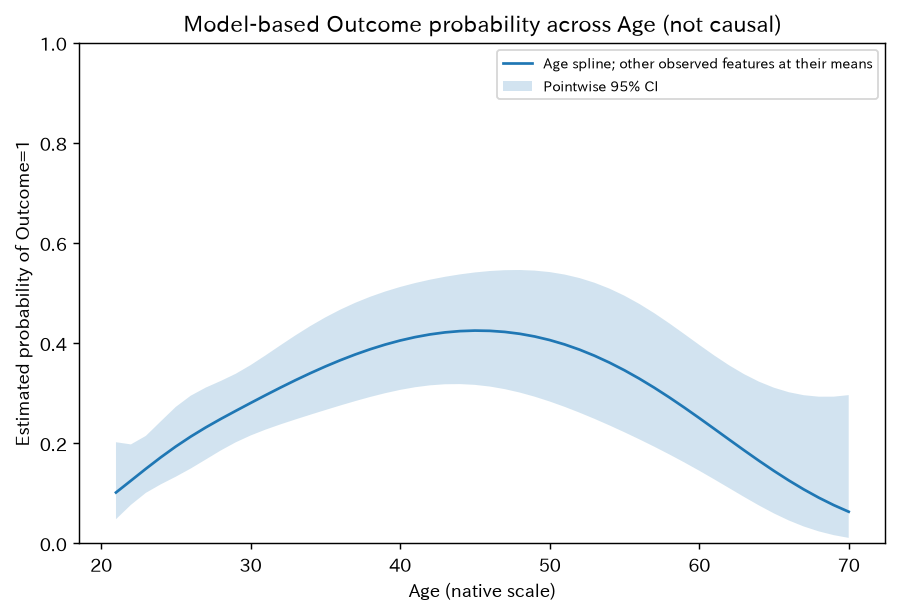

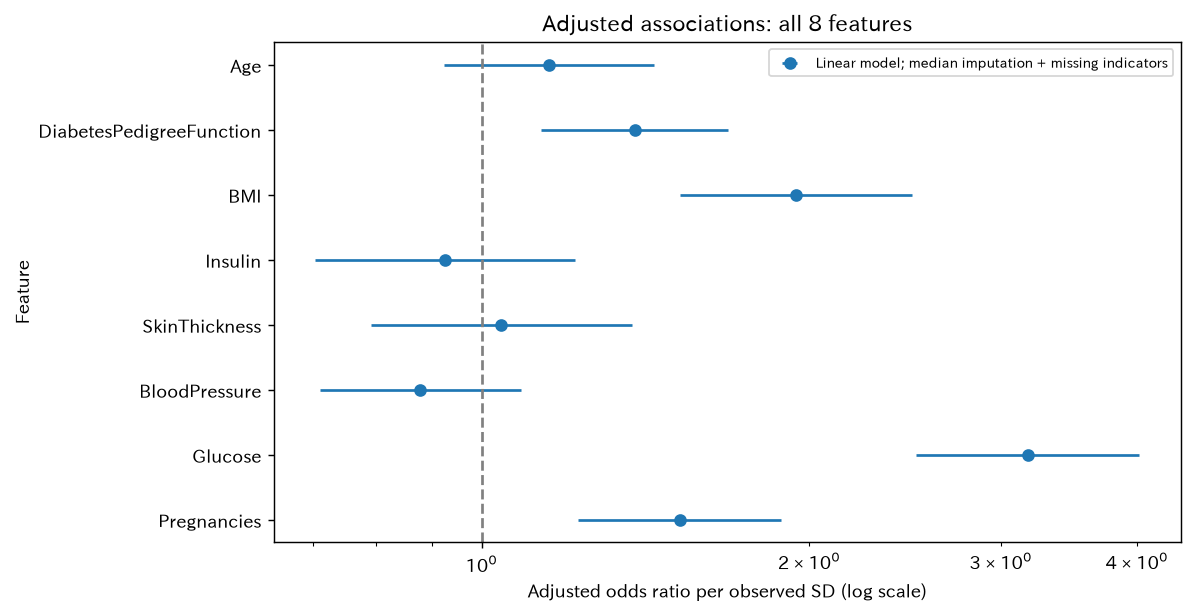

### 反復2の引用用出力
```json
{"Age_spline_p_LR": 2.365e-05, "Glucose_OR_age_spline": 3.236985, "BMI_OR_age_spline": 1.850463, "Glucose_OR_log_model": 3.048077, "BMI_OR_log_model": 1.914501}
```

In [8]:
# 反復2：非線形性・歪んだ分布に対するモデル感度
with phase('iteration-2-functional-form'):
    import statsmodels.formula.api as smf
    from patsy import bs
    analysis_data = (clean[features].fillna(clean[features].median())-center)/scale
    for column in zero_missing:
        analysis_data[column+'_missing'] = clean[column].isna().astype(int)
    analysis_data['Outcome'] = clean.Outcome
    linear_formula = 'Outcome ~ ' + ' + '.join([*features,*[c+'_missing' for c in zero_missing]])
    linear_formula_model = smf.glm(linear_formula,data=analysis_data,family=sm.families.Binomial()).fit()
    assert np.isclose(linear_formula_model.llf,main_model.llf)
    spline_models = {}
    functional_rows = []
    nonlinear_test_rows = []
    for spline_columns in [['Age'],['Glucose'],['Age','Glucose']]:
        terms = [f'bs({column}, df=4, degree=3, include_intercept=False)' if column in spline_columns else column for column in features]
        formula = 'Outcome ~ ' + ' + '.join(terms+[c+'_missing' for c in zero_missing])
        fitted = smf.glm(formula,data=analysis_data,family=sm.families.Binomial()).fit()
        assert fitted.converged
        name = 'spline-'+'-'.join(spline_columns)
        spline_models[name] = fitted
        lr = 2*(fitted.llf-linear_formula_model.llf)
        extra_df = int(fitted.df_model-linear_formula_model.df_model)
        nonlinear_test_rows.append({'model':name,'LR':lr,'extra_df':extra_df,'p_LR':stats.chi2.sf(lr,extra_df),'AIC':fitted.aic})
        for column in features:
            if column not in fitted.params.index:
                continue
            ci = fitted.conf_int().loc[column]
            functional_rows.append({'model':name,'feature':column,'OR_per_observed_SD':np.exp(fitted.params[column]),'low':np.exp(ci.iloc[0]),'high':np.exp(ci.iloc[1])})
    nonlinear_tests = pd.DataFrame(nonlinear_test_rows)
    display(nonlinear_tests)
    display(pd.DataFrame(functional_rows).round(6))
    log_data = analysis_data.drop(columns='Outcome').copy()
    for column in ['Insulin','DiabetesPedigreeFunction']:
        observed_log = np.log1p(clean[column])
        log_data[column] = (observed_log.fillna(observed_log.median())-observed_log.mean())/observed_log.std(ddof=1)
    log_model = sm.GLM(clean.Outcome,sm.add_constant(log_data),family=sm.families.Binomial()).fit()
    assert log_model.converged
    log_rows = []
    for column in features:
        ci = log_model.conf_int().loc[column]
        log_rows.append({'feature':column,'OR':np.exp(log_model.params[column]),'low':np.exp(ci.iloc[0]),'high':np.exp(ci.iloc[1])})
    display(pd.DataFrame(log_rows).round(6))
    print('Insulin/DPFのlogモデルのORはlog1p変換後1SDあたり。他の特徴のSDは主解析と共通。非線形モデルのAge/Glucoseは単一のORで要約しない。')
    age_spline = spline_models['spline-Age']
    profile = pd.DataFrame(0.0,index=range(50),columns=analysis_data.drop(columns='Outcome').columns)
    age_grid = np.linspace(21,70,50)
    profile['Age'] = (age_grid-center['Age'])/scale['Age']
    prediction = age_spline.get_prediction(profile).summary_frame()
    fig,ax = plt.subplots(figsize=(8,5))
    ax.plot(age_grid,prediction['mean'],label='Age spline; other observed features at their means')
    ax.fill_between(age_grid,prediction['mean_ci_lower'],prediction['mean_ci_upper'],alpha=.2,label='Pointwise 95% CI')
    ax.set(title='Model-based Outcome probability across Age (not causal)',xlabel='Age (native scale)',ylabel='Estimated probability of Outcome=1')
    ax.set_ylim(0,1)
    ax.legend(fontsize=8)
    show_figure(fig)
    fig,ax = plt.subplots(figsize=(9,5))
    points = adjusted.loc[features]
    ax.errorbar(points.adjusted_OR_per_SD,points.index,xerr=[points.adjusted_OR_per_SD-points.CI_low,points.CI_high-points.adjusted_OR_per_SD],fmt='o',label='Linear model; median imputation + missing indicators')
    ax.axvline(1,color='gray',linestyle='--')
    ax.set_xscale('log')
    ax.set(title='Adjusted associations: all 8 features',xlabel='Adjusted odds ratio per observed SD (log scale)',ylabel='Feature')
    ax.legend(fontsize=8)
    show_figure(fig)
    functional_summary = {'Age_spline_p_LR':round(float(nonlinear_tests.iloc[0].p_LR),8),
      'Glucose_OR_age_spline':round(float(np.exp(age_spline.params['Glucose'])),6),
      'BMI_OR_age_spline':round(float(np.exp(age_spline.params['BMI'])),6),
      'Glucose_OR_log_model':round(float(np.exp(log_model.params['Glucose'])),6),
      'BMI_OR_log_model':round(float(np.exp(log_model.params['BMI'])),6)}
    display(Markdown('### 反復2の引用用出力\n```json\n'+json.dumps(functional_summary)+'\n```'))


反復2結果：年齢の非線形項追加の探索的LR検定p=2.365e-05で適合が改善した。年齢を調整しても「妊娠回数の独立関連がある」とした単純な結論はモデル依存で、年齢スプラインではCIが1を含む。Glucose・BMIの正の関連はlog変換と年齢形状変更後も残った。残る限界は事後モデル探索・単一補完・曲線形状の因果解釈不可。

```evidence
{"execution_count":8,"cited_value":"2.365e-05","claim_type":"associational"}
```

## 反復依頼履歴（続き）

### 反復3

**追加依頼原文**

年齢を非線形に扱うと妊娠回数の調整関連が弱まり、年齢曲線の高齢端では下降が見られます。年齢帯ごとの標本数とOutcome割合を確認し、スプライン自由度3〜5および60歳以下に限定した感度分析で、Glucose・BMI・家族歴指標・妊娠回数の結論が安定するか調べてください。高齢で糖尿病が予防されると解釈しないでください。

**選定理由**: 反復2では年齢スプラインの追加で適合が改善し、妊娠回数のORが約1.52から1.19に弱まった。高齢端の曲線を一般化すると誤解につながるため、観測範囲の支持と形状依存性を確認する。最大3回の最終反復。結果・証拠・限界は実行出力と根拠付きInsightに記録する。

,n,positive,positive_rate,Wilson_low,Wilson_high
Age,,,,,
21-29,396,84,0.212121,0.174721,0.255053
30-39,165,76,0.460606,0.386313,0.536692
40-49,118,65,0.550847,0.460909,0.637580
50-59,57,34,0.596491,0.466973,0.713825
60+,32,9,0.281250,0.155646,0.453745


,feature,age_max,spline_df,n,OR,low,high
0,Glucose,81,4,768,3.236985,2.542962,4.120421
1,Glucose,81,3,768,3.235987,2.542543,4.118558
2,Glucose,81,5,768,3.240853,2.544794,4.127300
3,Glucose,60,4,741,3.318201,2.589494,4.251973
4,Glucose,60,3,741,3.314933,2.586878,4.247893
5,Glucose,60,5,741,3.339084,2.603742,4.282100
6,BMI,81,4,768,1.850463,1.442209,2.374283
7,BMI,81,3,768,1.857514,1.448504,2.382017
8,BMI,81,5,768,1.860097,1.448960,2.387892
9,BMI,60,4,741,1.807729,1.401293,2.332049


,feature,stable,max_relative_deviation
0,Glucose,True,0.026437
1,BMI,True,0.040843
2,DiabetesPedigreeFunction,True,0.058708
3,Pregnancies,False,0.245848


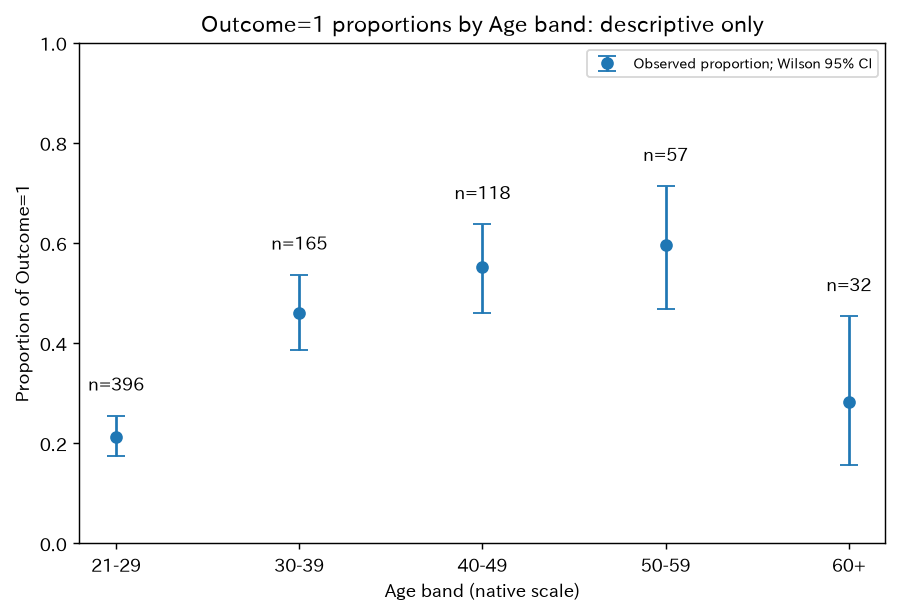

### 反復3の引用用出力
```json
{"Age60plus_n": 32, "Glucose_OR_age_variants_min": 3.235987, "Glucose_OR_age_variants_max": 3.339084, "BMI_OR_age_variants_min": 1.804528}
```

In [9]:
# 反復3：年齢形状の柔軟性と高齢端の少数標本
with phase('iteration-3-age-support-and-sensitivity'):
    from statsmodels.stats.proportion import proportion_confint
    age_bands = pd.cut(clean.Age,bins=[20,29,39,49,59,120],labels=['21-29','30-39','40-49','50-59','60+'])
    age_band_table = clean.groupby(age_bands,observed=True).Outcome.agg(['size','sum','mean']).rename(columns={'size':'n','sum':'positive','mean':'positive_rate'})
    low,high = proportion_confint(age_band_table.positive,age_band_table.n,method='wilson')
    age_band_table['Wilson_low'],age_band_table['Wilson_high'] = low,high
    display(age_band_table.round(6))
    age_cache = {}
    def fit_age_variant(age_max,spline_df):
        key = (age_max,spline_df)
        if key not in age_cache:
            work = analysis_data.loc[clean.Age<=age_max].copy()
            terms = [f'bs(Age, df={spline_df}, degree=3, include_intercept=False)' if column=='Age' else column for column in features]
            formula = 'Outcome ~ ' + ' + '.join(terms+[c+'_missing' for c in zero_missing])
            fitted = smf.glm(formula,data=work,family=sm.families.Binomial()).fit()
            assert fitted.converged
            age_cache[key] = (fitted,len(work))
        return age_cache[key]
    age_plan = sensitivity.SensitivityPlan(parameter_grid={'age_max':[81,60],'spline_df':[4,3,5]},max_runs=6)
    age_reports = {}
    age_rows = []
    for column in ['Glucose','BMI','DiabetesPedigreeFunction','Pregnancies']:
        report = sensitivity.run_sensitivity(age_plan,lambda age_max,spline_df: fit_age_variant(age_max,spline_df)[0].params[column],stability_tolerance=.20)
        age_reports[column] = report
        for result in report.results:
            fitted,n = fit_age_variant(**result.specification)
            ci = fitted.conf_int().loc[column]
            age_rows.append({'feature':column,**result.specification,'n':n,'OR':np.exp(result.value),'low':np.exp(ci.iloc[0]),'high':np.exp(ci.iloc[1])})
    age_sensitivity = pd.DataFrame(age_rows)
    display(age_sensitivity.round(6))
    age_stability = pd.DataFrame([{'feature':column,'stable':report.stable,'max_relative_deviation':report.max_relative_deviation} for column,report in age_reports.items()])
    display(age_stability)
    fig,ax = plt.subplots(figsize=(8,5))
    ax.errorbar(age_band_table.index.astype(str),age_band_table.positive_rate,yerr=[age_band_table.positive_rate-age_band_table.Wilson_low,age_band_table.Wilson_high-age_band_table.positive_rate],fmt='o',capsize=5,label='Observed proportion; Wilson 95% CI')
    for pos,(_,row) in enumerate(age_band_table.iterrows()):
        ax.text(pos,min(row.Wilson_high+.05,.96),f'n={int(row.n)}',ha='center')
    ax.set(title='Outcome=1 proportions by Age band: descriptive only',xlabel='Age band (native scale)',ylabel='Proportion of Outcome=1')
    ax.set_ylim(0,1)
    ax.legend(fontsize=8)
    show_figure(fig)
    display(Markdown('### 反復3の引用用出力\n```json\n'+json.dumps({'Age60plus_n':int(age_band_table.loc['60+','n']), 'Glucose_OR_age_variants_min':round(float(age_sensitivity.loc[age_sensitivity.feature=='Glucose','OR'].min()),6),'Glucose_OR_age_variants_max':round(float(age_sensitivity.loc[age_sensitivity.feature=='Glucose','OR'].max()),6),'BMI_OR_age_variants_min':round(float(age_sensitivity.loc[age_sensitivity.feature=='BMI','OR'].min()),6)},ensure_ascii=False)+'\n```'))


反復3結果：60歳以上は32件と少なく、高齢端の割合下降を予防効果と解釈しない。年齢形状/60歳以下を変える6仕様ではGlucoseのORが3.235987–3.339084、BMIと家族歴指標もstable=True、妊娠回数はstable=False。残る限界は高齢端の選択と一般化不能。

```evidence
{"execution_count":9,"cited_value":"32","claim_type":"associational"}
```

## 使用したJupytermindモジュール
以下は直接importし、関数・クラス・メソッドを実際に呼び出したもののみ。制御Notebookからの直接利用は明示した。内部依存関係は使用済みに数えない。

| モジュール（ai_data_scientist配下） | 直接使用したAPI | 使用目的 |
|---|---|---|
| project_manager | resolve_project, ensure_notebook, ensure_data_dir, enqueue_write | slug検証、保存先作成、データ配置、Notebookの直列書込み（セル構築は制御Notebook） |
| language_router | detect_language | 日本語判定 |
| lifecycle | register_run, mark_execution_start/end, mark_write_start/end, is_cancel_requested, mark_completed, get_run_status | run_idと実行・書込み・終了状態の記録 |
| ingestion | SourceSpec, ingest | 取得CSV読込み・行数上限確認 |
| cleaning | clean_dataset | 重複除去と行・列への影響確認 |
| eda | explore | 記述統計・型・非欠損件数・欠損率 |
| stats_analysis | correlation | 二値Outcomeとの点双列相関と日本語の解釈 |
| visualization | render_chart, build_image_output | 観測数棒グラフの描画とPNG MIME出力。複雑な比較図はmatplotlib＋build_image_output |
| data_definition | FieldValue, build_manifest, DataDefinitionManifest.unresolved_fields | 変数定義・単位・出典の確度。inferredは別途列挙 |
| analysis_assumptions | Assumption, AnalysisAssumptionManifest, check_manifest | 分析前提・関連スコープ・未検証前提の警告 |
| data_quality | detect_anomalies | 範囲・許容カテゴリ・欠損の意味的検査 |
| sensitivity | SensitivityPlan, run_sensitivity | 欠損処理・Winsor化・年齢形状・対象範囲の安定性確認 |
| insight_engine | extract_cited_value, record_insight | 実行出力から引用しevidence manifest付きInsightを保存（制御Notebook） |
| notebook_audit | audit_notebook(visual_audit=True) | 実行・エラー・根拠参照・図表監査（最終セルと制御Notebook） |

**非利用/適用不可**: mcp_gateway.run_and_recordはCLIツール接続をPython MCPClientとして受け渡す手段がないため未利用（CLI接続上の制約であり、本体の不具合とは断定しない）。dataset_validation.compare_datasetsおよびdata_quality.validate_anomaliesは独立参照データがないため未利用。anomaly_detectionのz-scoreは歪んだ分布を一律異常とみなすため不適用。機械学習拡張は目的外。bootstrap/GLM/スプライン/Wilson CI/VIFはnumpy/scipy/statsmodels/patsyの直接利用であり、Jupytermindの機能として数えない。

今回の実行でmark_failedは例外時のハンドラとしてコードに定義されているが、正常終了経路では呼び出していないため実利用一覧には含めない。


## Jupytermind改善候補

### 候補1：描画レイアウトによる長いラベルの切れ
**分類**: visualization.render_chartの描画品質の不具合疑い（再現済み）。**再現条件**: 初回chartsセルのbar図でPregnancies/DiabetesPedigreeFunctionなど長い列名をx目盛りにし、日本語title/xlabel/ylabelを指定。**期待する挙動**: 目盛りとxlabelが画像内に収まり読める。**実際の挙動**: fig.savefigの標準余白で下端が切れ、xlabelも見えない。**影響**: 特徴の比較と軸の意味が読めない。**回避策**: 欠損率図を横棒にし、fig.savefig(bbox_inches='tight')で余白を調整。最終成果物では解消。**関係するセル/ログ**: charts、制御Notebookのinitial-review-and-iteration-1-plan、data/initial-visual-audit.json。初回の自動visual_findingsは空であった。

### 候補2：visual_auditの目視可読性検出範囲
**分類**: notebook_auditの機能不足/拡張候補（ヒューリスティック仕様の限界で、仕様違反とは断定しない）。**再現条件**: 上記のラベル切れ画像にtitle/xlabel/ylabel/legend/missing_glyphsメタデータを付与してvisual_audit=True。**期待する挙動**: ラベル切れ・画像外の要素を警告するか、検査対象外と明示する。**実際の挙動**: chart metadataと画像密度による検査ではok=True、visual_findings=空。**影響**: 自動監査だけでは可読性を保証できない。**回避策**: 全図を目視確認し、ラベル切れと重なりを直す。**関係するセル/ログ**: 初回charts/initial-visual-audit.json。最終監査合格は人による目視確認も併用した結果。

### 他システムとの切り分け
指定ucimlのHTTP403はKaggle API/当該データセットのアクセス側の問題。対応版harsh146からSDKで取得した。Filesystem MCPの許可ディレクトリが別の場所だった問題はツール設定であり、Jupytermind本体の不具合ではない。最初に検索の先頭ページだけで指定slugがないと判断した点は分析担当側の探索不足で、修正して指定slugと対応版を照会した。ベンチマークランナーは起動していないため、その機能の評価・不具合判断は行わない。

## 初期取得履歴（最終採用データとは区別）
最初の検索確認は先頭ページだけで指定slugが見つからずLookupErrorとして扱い、Plotly CSVを2026-10-01T18:32:53.214381+00:00に一時取得した。探索を修正し、指定slugのファイルAPIも確認したがHTTPErrorとなり2026-10-01T18:33:15.873031+00:00に同CSVを再取得した。URLは https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv 、ファイルはdiabetes.csv、SHA-256は両方とも698c203a14aa31941d2251175330c9199f3ccdb31597abbba2a3e35416257a72。初期フォールバック理由は該当時点のKaggle取得失敗であり、当時の公開CSVとuciml掲載版の完全な同一性は保証されない。その後検索候補の照会を継続しharsh146版のKaggle取得に成功したため、**最終分析・全セル再実行はKaggle APIで新たに取得したファイル**を使用する。同じSHAは取得バイト列の一致のみを示し、取得できなかったuciml版との同一性を証明しない。

## 今回の再確認における切り分け
上記2候補は既存の初回解析で記録された候補を保持したもの。今回は修正後の7図をJupyter MCP出力で目視確認し、ラベル欠落・切れ・比較を妨げる重なりは見られなかった。今回新たなJupytermind本体の不具合候補はなし。CLIからのPython MCPClient注入不可はCLI接続上の制約、ucimlの403はKaggleアクセス側の問題、制御Notebookの絶対パスが受理されなかった問題はJupyter MCP/Contents APIのパス制約として切り分ける。新規取得先・候補選択・書込み追跡の調整は分析担当の取得コードを改善したもので、Jupytermind本体の不具合とはしない。関係セルはacquisition、final-audit、制御Notebookの今回の再確認・確定保存セル、ログはprovenance.json/replay-phase-log.json/review-control-log.json。ベンチマークランナーは未起動。


In [10]:
# 日本語の最終結論・反復報告・再実行時の数値照合
with phase('final-summary-and-replay-check'):
    current_fingerprint = {'sha256':sha256,'n':len(clean),'positive':int(clean.Outcome.sum()),
        'Glucose_r':float(association.loc['Glucose','point_biserial_r']),
        'BMI_r':float(association.loc['BMI','point_biserial_r']),
        'Glucose_beta':float(main_model.params['Glucose']), 'BMI_beta':float(main_model.params['BMI']),
        'Age_spline_llf':float(spline_models['spline-Age'].llf),
        'Glucose_age_min_OR':float(age_sensitivity.loc[age_sensitivity.feature=='Glucose','OR'].min())}
    first_fingerprint = json.loads((data_dir/'first-analysis-fingerprint.json').read_text(encoding='utf-8'))
    for key,value in current_fingerprint.items():
        if isinstance(value,(float,int)):
            assert np.isclose(value,first_fingerprint[key],rtol=1e-9,atol=1e-10), f'再実行値が不一致: {key}'
        else:
            assert value == first_fingerprint[key], f'再実行ファイルが不一致: {key}'
    print('初回解析と再実行のSHA・主要数値の照合: 一致')
    print('照合記録:', json.dumps(current_fingerprint,ensure_ascii=False))
    interpretation_text = f'''## 日本語の結論
この標本768件（Outcome=1は268件、34.9%）では、**Glucoseが最も明瞭な正の関連**を示した。ゼロを欠損にした観測値の点双列相関は{association.loc['Glucose','point_biserial_r']:.3f}、Hedges gは{association.loc['Glucose','hedges_g']:.2f}（bootstrap 95%CI {association.loc['Glucose','g_ci_low']:.2f}–{association.loc['Glucose','g_ci_high']:.2f}）。BMIと家族歴指標も、調整・年齢形状の検討を通じて正の関連が残った。

主解析の調整OR（観測値1SDあたり）はGlucose {adjusted.loc['Glucose','adjusted_OR_per_SD']:.2f}（95%CI {adjusted.loc['Glucose','CI_low']:.2f}–{adjusted.loc['Glucose','CI_high']:.2f}）、BMI {adjusted.loc['BMI','adjusted_OR_per_SD']:.2f}（{adjusted.loc['BMI','CI_low']:.2f}–{adjusted.loc['BMI','CI_high']:.2f}）、家族歴指標 {adjusted.loc['DiabetesPedigreeFunction','adjusted_OR_per_SD']:.2f}（{adjusted.loc['DiabetesPedigreeFunction','CI_low']:.2f}–{adjusted.loc['DiabetesPedigreeFunction','CI_high']:.2f}）。Glucoseの係数は欠損処理・Winsor化4仕様で最大相対変動{sensitivity_reports['Glucose'].max_relative_deviation:.1%}、stable={sensitivity_reports['Glucose'].stable}。BMIは同検討で{ sensitivity_reports['BMI'].max_relative_deviation:.1%}変動しstable=Falseのため、方向は一貫しても大きさまで頑健とは言わない。

年齢の単変量関連を単調な独立効果と解釈しない。年齢を柔軟に扱うと妊娠回数のORは{np.exp(spline_models['spline-Age'].params['Pregnancies']):.2f}となりCIが1を含んだ。年齢モデルの6仕様でも妊娠回数は不安定。Insulin・皮下厚・血圧は単変量で正の関連があっても、他特徴と同時に調整した関連は不確実であり、「関係がない」とも「独立した危険因子」とも断定しない。

**これは相関・条件付き関連であり、因果ではない。** Glucoseの測定とOutcome定義の時間順序・診断基準を検証できず、ラベルとの定義上の近さもあり得る。年齢曲線の高齢端の下降は少数標本・選択・未測定要因・関数形の影響を受け得るため予防効果を意味しない。一般集団や将来の糖尿病発症、介入による改善への外挿は行わない。

## 反復結果・根拠・残る限界
1. **反復1（iteration-1）**: 全8特徴の完全例392件と除外376件ではOutcome=1割合が33.2%対36.7%、年齢中央値が27対32。Fisher検定の非有意は欠損がランダムという証明ではない。VIF最大{vif_table.VIF.max():.2f}と極端な共線性は確認されなかった。5特徴の完全例752件と中央値補完768件ではGlucose/BMIの関連は近い。限界: 欠損機序と個人ID不在による独立性は未検証。
2. **反復2（iteration-2）**: 年齢スプラインで適合改善（探索的LR p={functional_summary['Age_spline_p_LR']:.3g}）。妊娠回数の独立した関連の断定を取り下げる。log変換モデルでもGlucose/BMIは正の関連。限界: 非線形モデルの事後選択、単一補完の不確実性、曲線CIは点ごとのCIで同時信頼帯ではない。
3. **反復3（iteration-3）**: 60歳以上は32件。年齢スプライン自由度3–5、全範囲/60歳以下でGlucoseのORは{age_sensitivity.loc[age_sensitivity.feature=='Glucose','OR'].min():.2f}–{age_sensitivity.loc[age_sensitivity.feature=='Glucose','OR'].max():.2f}、BMI/家族歴指標もこの6仕様ではstable=True。限界: 年齢制限は対象を変える。高齢端の下降の機序はこのデータから識別できない。

**反復停止理由**: 3回の上限に達し、主要な関連の方向とモデル依存な結論を区別できた。残る重要点（診断定義、欠損機序、外的妥当性、未測定交絡）は同じCSVの追加モデル探索では解決できない。単位・母集団のinferred/unknownおよび前提manifestの3警告は解決済み扱いにしない。
'''
    display(Markdown(interpretation_text))
    display(Markdown('### 最終照合値\n```json\n'+json.dumps({'Glucose_r':round(association.loc['Glucose','point_biserial_r'],6), 'Glucose_OR':round(adjusted.loc['Glucose','adjusted_OR_per_SD'],6), 'BMI_OR':round(adjusted.loc['BMI','adjusted_OR_per_SD'],6),'DPF_OR':round(adjusted.loc['DiabetesPedigreeFunction','adjusted_OR_per_SD'],6),'Pregnancies_OR_age_spline':round(float(np.exp(spline_models['spline-Age'].params['Pregnancies'])),6),'Insulin_missing_pct':round(missing_table.loc['Insulin','missing_pct'],6)},ensure_ascii=False)+'\n```'))
    phase_log.append({'phase':'artifact-write','event':'start','utc':datetime.now(timezone.utc).isoformat()})
    lifecycle.mark_write_start(run_id)
    try:
        manifests = {'provenance':provenance,'definition':asdict(definition_manifest),'assumptions':asdict(assumptions_manifest),
           'assumption_findings':[asdict(f) for f in assumption_findings],
           'sensitivity':{column:asdict(report) for column,report in sensitivity_reports.items()},
           'age_sensitivity':{column:asdict(report) for column,report in age_reports.items()},
           'fingerprint':current_fingerprint}
        (data_dir/'analysis-manifests.json').write_text(json.dumps(manifests,ensure_ascii=False,indent=2,default=str),encoding='utf-8')
    finally:
        lifecycle.mark_write_end(run_id)
        phase_log.append({'phase':'artifact-write','event':'end','utc':datetime.now(timezone.utc).isoformat()})


初回解析と再実行のSHA・主要数値の照合: 一致
照合記録: {"sha256": "698c203a14aa31941d2251175330c9199f3ccdb31597abbba2a3e35416257a72", "n": 768, "positive": 268, "Glucose_r": 0.4946502590810321, "BMI_r": 0.3136804821984416, "Glucose_beta": 1.1551828756775344, "BMI_beta": 0.6647464786960071, "Age_spline_llf": -339.9513467135265, "Glucose_age_min_OR": 3.235986892120672}


## 日本語の結論
この標本768件（Outcome=1は268件、34.9%）では、**Glucoseが最も明瞭な正の関連**を示した。ゼロを欠損にした観測値の点双列相関は0.495、Hedges gは1.19（bootstrap 95%CI 1.02–1.37）。BMIと家族歴指標も、調整・年齢形状の検討を通じて正の関連が残った。

主解析の調整OR（観測値1SDあたり）はGlucose 3.17（95%CI 2.51–4.02）、BMI 1.94（1.52–2.49）、家族歴指標 1.38（1.13–1.69）。Glucoseの係数は欠損処理・Winsor化4仕様で最大相対変動1.2%、stable=True。BMIは同検討で26.5%変動しstable=Falseのため、方向は一貫しても大きさまで頑健とは言わない。

年齢の単変量関連を単調な独立効果と解釈しない。年齢を柔軟に扱うと妊娠回数のORは1.19となりCIが1を含んだ。年齢モデルの6仕様でも妊娠回数は不安定。Insulin・皮下厚・血圧は単変量で正の関連があっても、他特徴と同時に調整した関連は不確実であり、「関係がない」とも「独立した危険因子」とも断定しない。

**これは相関・条件付き関連であり、因果ではない。** Glucoseの測定とOutcome定義の時間順序・診断基準を検証できず、ラベルとの定義上の近さもあり得る。年齢曲線の高齢端の下降は少数標本・選択・未測定要因・関数形の影響を受け得るため予防効果を意味しない。一般集団や将来の糖尿病発症、介入による改善への外挿は行わない。

## 反復結果・根拠・残る限界
1. **反復1（iteration-1）**: 全8特徴の完全例392件と除外376件ではOutcome=1割合が33.2%対36.7%、年齢中央値が27対32。Fisher検定の非有意は欠損がランダムという証明ではない。VIF最大1.62と極端な共線性は確認されなかった。5特徴の完全例752件と中央値補完768件ではGlucose/BMIの関連は近い。限界: 欠損機序と個人ID不在による独立性は未検証。
2. **反復2（iteration-2）**: 年齢スプラインで適合改善（探索的LR p=2.36e-05）。妊娠回数の独立した関連の断定を取り下げる。log変換モデルでもGlucose/BMIは正の関連。限界: 非線形モデルの事後選択、単一補完の不確実性、曲線CIは点ごとのCIで同時信頼帯ではない。
3. **反復3（iteration-3）**: 60歳以上は32件。年齢スプライン自由度3–5、全範囲/60歳以下でGlucoseのORは3.24–3.34、BMI/家族歴指標もこの6仕様ではstable=True。限界: 年齢制限は対象を変える。高齢端の下降の機序はこのデータから識別できない。

**反復停止理由**: 3回の上限に達し、主要な関連の方向とモデル依存な結論を区別できた。残る重要点（診断定義、欠損機序、外的妥当性、未測定交絡）は同じCSVの追加モデル探索では解決できない。単位・母集団のinferred/unknownおよび前提manifestの3警告は解決済み扱いにしない。


### 最終照合値
```json
{"Glucose_r": 0.49465, "Glucose_OR": 3.174604, "BMI_OR": 1.943998, "DPF_OR": 1.382029, "Pregnancies_OR_age_spline": 1.189143, "Insulin_missing_pct": 48.697917}
```

最終Insight：年齢を非線形に扱うと妊娠回数のORは1.189143（CIが1を含む）となり、独立した正の関連の断定を取り下げる。Glucose・BMI・家族歴指標が主な条件付き関連だが、GlucoseとOutcome定義の近接性、測定時点、欠損、未測定交絡は未解決。因果効果・将来発症・介入効果は示さない。

```evidence
{"execution_count":10,"cited_value":"1.189143","claim_type":"associational"}
```

## 再実行・引渡し監査記録

新しいカーネルで全11コードセルを上からJupyter MCPで再実行した。Kaggle SDKで新規取得したファイルのSHA-256と主要数値は初回解析と一致。7図と7件の根拠付きInsightを保存し、全セル終了後のvisual_audit=True監査はok=True、未実行・エラー・visual_findingsは空。ライフサイクルはcompleted、実行・書込み・ロックは0。3回の反復原文と選定理由・結果・証拠・限界を保持。診断定義・欠損機序・独立性・外的妥当性の未解決点は解消済みとはしない。

```json
{
  "run_id": "v020-exp-09",
  "status": "completed",
  "method": "existing analysis reviewed; kernel restart; all 11 code cells executed sequentially with Jupyter MCP; fresh Kaggle download",
  "verified_at_utc": "2026-10-01T20:17:15.689748+00:00",
  "executions": [
    {
      "id": "setup",
      "execution_count": 1
    },
    {
      "id": "acquisition",
      "execution_count": 2
    },
    {
      "id": "definition-cleaning",
      "execution_count": 3
    },
    {
      "id": "comparison",
      "execution_count": 4
    },
    {
      "id": "charts",
      "execution_count": 5
    },
    {
      "id": "adjusted-sensitivity",
      "execution_count": 6
    },
    {
      "id": "iteration-1",
      "execution_count": 7
    },
    {
      "id": "iteration-2",
      "execution_count": 8
    },
    {
      "id": "iteration-3",
      "execution_count": 9
    },
    {
      "id": "final-summary",
      "execution_count": 10
    },
    {
      "id": "final-audit",
      "execution_count": 12
    }
  ],
  "image_output_count": 7,
  "numerical_replay_match": true,
  "sha256_replay_match": true,
  "audit": {
    "path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-09-diabetes/notebooks/kaggle-v020-kaggle-exp-09-diabetes.ipynb",
    "nbformat_valid": true,
    "code_cell_count": 11,
    "executed_code_cell_count": 11,
    "unexecuted_cell_indices": [],
    "error_cell_indices": [],
    "chart_cell_indices": [
      8,
      15,
      18
    ],
    "insight_cell_count": 7,
    "findings": [],
    "visual_findings": []
  },
  "audit_ok": true,
  "lifecycle": {
    "run_id": "v020-exp-09",
    "state": "completed",
    "active_cell_executions": 0,
    "pending_notebook_writes": 0,
    "locks_held": 0,
    "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-09-diabetes/notebooks/kaggle-v020-kaggle-exp-09-diabetes.ipynb",
    "reason": null
  },
  "provenance": {
    "requested_owner_dataset_slug": "uciml/pima-indians-diabetes-database",
    "owner_dataset_slug": "harsh146/pima-indians-diabetes",
    "source_kind": "kaggle",
    "source_url": "https://www.kaggle.com/datasets/harsh146/pima-indians-diabetes",
    "retrieved_filename": "diabetes.csv",
    "retrieved_at_utc": "2026-10-01T20:14:59.960109+00:00",
    "sha256": "698c203a14aa31941d2251175330c9199f3ccdb31597abbba2a3e35416257a72",
    "search_query": "pima indians diabetes",
    "candidate_failures": [
      {
        "slug": "uciml/pima-indians-diabetes-database",
        "stage": "dataset_list_files",
        "error_type": "HTTPError",
        "http_status": 403,
        "reason": "秘密情報保護のためSDK例外本文・headers・設定は保存しない"
      },
      {
        "slug": "ahmedgamelwaly/pima-indians-diabetes",
        "stage": "dataset_list_files",
        "error_type": "FileNotFoundError",
        "http_status": null,
        "reason": "秘密情報保護のためSDK例外本文・headers・設定は保存しない"
      }
    ],
    "search_results": [
      "agileteam/bigdatacertificationkr",
      "ahmedgamelwaly/pima-indians-diabetes",
      "ameythakur20/data-science-machine-learning-and-ai-using-python",
      "amineipad/diabetes-dataset",
      "danushkumarv/diabetes-dataset",
      "fathyfathysahlool/pima-and-indians-diabetes",
      "harsh146/pima-indians-diabetes",
      "jamaltariqcheema/pima-indians-diabetes-dataset",
      "jameshramos/pima-indians-diabetes",
      "kumargh/pimaindiansdiabetescsv",
      "lianglirong/pima-indians-onset-of-diabetes",
      "maunish/prima-indiansdiabetes",
      "mragpavank/diabetes",
      "philanipro/pima-indians-diabetes",
      "prashantsatpute/pima-indians-diabetes",
      "rahibvk/real-diabetes-lab-results-and-biomarkers-anti-pima",
      "salihacur/diabetes",
      "sandeep2812/pimaindiansdiabetes",
      "semakulapaul/pimaindiansdiabetes",
      "wanglaiqi/pimaindiansdiabetesdata"
    ],
    "kaggle_file_names": [
      "diabetes.csv"
    ],
    "kaggle_failure": null,
    "fallback_reason": null,
    "legacy_note_url_confirmed": null,
    "identity_warning": "対応する別ownerのKaggle公開版。参照指定uciml版との完全な同一性は未検証"
  },
  "evidence_regenerated_with": "insight_engine.extract_cited_value + record_insight",
  "evidence_records": [
    {
      "insight_id": "30009c46",
      "evidence_cell_id": "comparison",
      "execution_count": 4,
      "cited_value": "0.49465"
    },
    {
      "insight_id": "8f910b51",
      "evidence_cell_id": "comparison",
      "execution_count": 4,
      "cited_value": "48.697917"
    },
    {
      "insight_id": "ddc0d93d",
      "evidence_cell_id": "adjusted-sensitivity",
      "execution_count": 6,
      "cited_value": "3.174604"
    },
    {
      "insight_id": "8fce9470",
      "evidence_cell_id": "iteration-1",
      "execution_count": 7,
      "cited_value": "392"
    },
    {
      "insight_id": "91efadfb",
      "evidence_cell_id": "iteration-2",
      "execution_count": 8,
      "cited_value": "2.365e-05"
    },
    {
      "insight_id": "fefc2d86",
      "evidence_cell_id": "iteration-3",
      "execution_count": 9,
      "cited_value": "32"
    },
    {
      "insight_id": "34a23067",
      "evidence_cell_id": "final-summary",
      "execution_count": 10,
      "cited_value": "1.189143"
    }
  ],
  "manual_visual_review": "今回のJupyter MCP出力7図を目視確認。文字・軸・凡例・CI・標本数・長いラベルが読めることを確認。",
  "unresolved_assumption_warnings": [
    {
      "code": "unresolved_conclusion_critical_assumption",
      "severity": "warning",
      "message": "Conclusion-critical assumption 'zero-as-missing' has status 'assumed', not verified/tested.",
      "assumption_id": "zero-as-missing"
    },
    {
      "code": "unresolved_conclusion_critical_assumption",
      "severity": "warning",
      "message": "Conclusion-critical assumption 'independent-rows' has status 'assumed', not verified/tested.",
      "assumption_id": "independent-rows"
    },
    {
      "code": "unresolved_conclusion_critical_assumption",
      "severity": "warning",
      "message": "Conclusion-critical assumption 'outcome-semantics' has status 'assumed', not verified/tested.",
      "assumption_id": "outcome-semantics"
    }
  ],
  "scope_limit": "関連の方向と大きさを区別。BMI/家族歴指標は欠損処理4仕様でstable=False。因果・将来発症・外的妥当性は未検証。",
  "iteration_history": "既存の追加依頼原文3回を保持し、全3反復のコード・結果を今回のデータで再実行。4回目は実施せず。",
  "analysis_execution_route": "Jupyter MCP only; no terminal, subprocess, external script, or task agent"
}
```

In [12]:
# 再実行した根拠セルの実行番号にevidenceを再接続する
with phase('evidence-reference-refresh'):
    evidence_ids = {6:'comparison',7:'comparison',10:'adjusted-sensitivity',13:'iteration-1',16:'iteration-2',19:'iteration-3',23:'final-summary'}
    def refresh_evidence(notebook):
        counts = {cell.id:cell.get('execution_count') for cell in notebook.cells if cell.cell_type=='code'}
        for index,code_id in evidence_ids.items():
            cell = notebook.cells[index]
            match = re.search(r'```evidence\n(.*?)\n```',cell.source,re.DOTALL)
            manifest = json.loads(match.group(1))
            manifest['execution_count'] = counts[code_id]
            cell.source = cell.source[:match.start()] + '```evidence\n' + json.dumps(manifest,separators=(',',':')) + '\n```' + cell.source[match.end():]
    write_notebook(refresh_evidence)
# Notebook監査とライフサイクルの終了
with phase('final-notebook-audit'):
    audit_report = notebook_audit.audit_notebook(handle.notebook_path,visual_audit=True)
    print('Notebook監査（このセルの実行途中）:', json.dumps(asdict(audit_report),ensure_ascii=False))
    print('audit_ok:',audit_report.ok)
    if not audit_report.ok or audit_report.visual_findings:
        raise RuntimeError('Notebook/図表監査に未解決の指摘がある')
lifecycle.mark_completed(run_id)
final_status = lifecycle.get_run_status(run_id)
assert final_status.state == 'completed'
assert final_status.active_cell_executions == 0 and final_status.pending_notebook_writes == 0 and final_status.locks_held == 0
print('終了状態:',json.dumps(asdict(final_status),ensure_ascii=False))
lifecycle.mark_write_start(run_id)
try:
    (data_dir/'replay-phase-log.json').write_text(json.dumps(phase_log,ensure_ascii=False,indent=2),encoding='utf-8')
    (data_dir/'lifecycle-final.json').write_text(json.dumps(asdict(final_status),ensure_ascii=False,indent=2),encoding='utf-8')
finally:
    lifecycle.mark_write_end(run_id)
print('全セル終了後の保存済みNotebookは制御Notebookから再監査し、handoff-audit.jsonとNotebook metadataへ記録する。')


Notebook監査（このセルの実行途中）: {"path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-09-diabetes/notebooks/kaggle-v020-kaggle-exp-09-diabetes.ipynb", "nbformat_valid": true, "code_cell_count": 11, "executed_code_cell_count": 10, "unexecuted_cell_indices": [], "error_cell_indices": [], "chart_cell_indices": [8, 15, 18], "insight_cell_count": 7, "findings": [{"severity": "warning", "message": "Trailing cell invokes audit_notebook and has not finished executing yet; excluded from unexecuted-cell findings.", "cell_index": 24}], "visual_findings": []}
audit_ok: True
終了状態: {"run_id": "v020-exp-09", "state": "completed", "active_cell_executions": 0, "pending_notebook_writes": 0, "locks_held": 0, "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-09-diabetes/notebooks/kaggle-v020-kaggle-exp-09-diabetes.ipynb", "reason": null}
全セル終了後の保存済みNotebookは制御Notebookから再監査し、handoff-audit.jsonとNotebook metadataへ記録する。
